Project ini bertujuan untuk menganalisis dataset ringkasan berita Liputan6 dan menentukan pendekatan summarization yang paling sesuai berdasarkan karakteristik data. Fokus utama analisis adalah membandingkan kecenderungan extractive dan abstractive summarization melalui eksplorasi panjang teks, rasio kompresi, serta tingkat overlap leksikal antara artikel dan ringkasan, lalu terakhir mencoba membuat summarization dengan model BERT

## Load File

### Load Library

In [1]:
import tarfile
import json
from pathlib import Path
import pandas as pd

Pada tahap awal, beberapa library dasar digunakan untuk membaca arsip dataset `.tar.gz`, memuat file JSON, mengelola path file, dan menyusun data ke dalam bentuk tabel.

### Path Archive

In [2]:
archive_path = Path("liputan6_data.tar.gz")

Kami mendefiniskan lokasi file dataset `liputan6_data.tar.gz` yang akan dibaca pada proses berikutnya supaya tidak berulang

### Helper function untuk ubah token list -> text

In [3]:
def to_text(x):
    if x is None:
        return None

    if isinstance(x, list):
        if len(x) > 0 and isinstance(x[0], list):
            return " ".join(" ".join(map(str, sent)) for sent in x)
        return " ".join(map(str, x))

    return str(x)

Fungsi ini kami gunakan untuk mengubah isi data teks menjadi format string yang rapi. Jika data berupa list token atau list of lists token, isinya akan digabung menjadi teks utuh agar lebih mudah dibaca dan diolah.

### Variable untuk menampung data per split

In [4]:
data_by_split = {
    "train": [],
    "dev": [],
    "test": []
}

n_ok = 0
n_bad_json = 0
n_unknown_split = 0

Next, kita siapkan penampung data berdasarkan split (`train`, `dev`, dan `test`) serta variabel penghitung untuk mencatat jumlah file yang berhasil dibaca, file JSON yang rusak, dan file dengan split yang tidak dikenali.

### Baca isi .tar.gz dan kelompokkan berdasarkan split

In [5]:
try:
    with tarfile.open(archive_path, "r|gz") as tar:
        while True:
            try:
                member = tar.next()
            except (EOFError, tarfile.ReadError, OSError) as e:
                print(f"Warning: archive berhenti di tengah jalan -> {e}")
                print("Data yang sudah berhasil dibaca tetap dipakai.")
                break

            if member is None:
                break

            if not member.isfile() or not member.name.endswith(".json"):
                continue

            try:
                f = tar.extractfile(member)
                if f is None:
                    continue

                obj = json.load(f)

            except (json.JSONDecodeError, EOFError, OSError, tarfile.ReadError) as e:
                n_bad_json += 1
                print(f"Skip {member.name} karena JSON/file error: {e}")
                continue

            parts = Path(member.name).parts
            split = None
            for s in ["train", "dev", "test"]:
                if s in parts:
                    split = s
                    break

            if split is None:
                n_unknown_split += 1
                print(f"Skip {member.name} karena split tidak dikenali")
                continue

            data_by_split[split].append({
                "id": obj.get("id"),
                "url": obj.get("url"),
                "clean_article": to_text(obj.get("clean_article")),
                "clean_summary": to_text(obj.get("clean_summary")),
                "extractive_summary": obj.get("extractive_summary"),
                "source_file": member.name,
            })
            n_ok += 1

except FileNotFoundError:
    print(f"File tidak ditemukan: {archive_path}")
except Exception as e:
    print(f"Warning: pembacaan dihentikan lebih awal -> {e}")
    print("Data yang sudah berhasil dibaca tetap dipakai.")

Next, kta baca isi file `.tar.gz` secara bertahap, lalu mengambil setiap file JSON yang valid dan mengelompokkannya ke dalam `train`, `dev`, atau `test` berdasarkan path file. Proses ini juga dibuat tahan error, sehingga jika ada JSON rusak atau archive terputus di tengah jalan, data yang sudah berhasil dibaca tetap disimpan dan bisa digunakan. 

Berdasarkan proses ini, tidak muncul log masalah yang berarti, sehingga pembacaan data dapat dianggap berjalan dengan aman. Artinya, file arsip berhasil diakses, file JSON yang relevan berhasil dimuat, dan data berhasil dipetakan ke split yang sesuai untuk tahap analisis berikutnya.

### Baca isi .tar.gz dan kelompokkan berdasarkan split

In [6]:
df_train = pd.DataFrame(data_by_split["train"])
df_dev   = pd.DataFrame(data_by_split["dev"])
df_test  = pd.DataFrame(data_by_split["test"])

Selanjutnya, data yang telah dikelompokkan berdasarkan split diubah menjadi tiga DataFrame terpisah, yaitu `df_train`, `df_dev`, dan `df_test`, agar lebih mudah dianalisis dan digunakan pada tahap berikutnya.

### Cek ringkasan hasil

In [8]:
print("Ringkasan pembacaan:")
print("Berhasil dibaca :", n_ok)
print("File JSON rusak :", n_bad_json)
print("Split tak dikenal:", n_unknown_split)

print("\nJumlah data per split:")
print("train:", len(df_train))
print("dev  :", len(df_dev))
print("test :", len(df_test))

Ringkasan pembacaan:
Berhasil dibaca : 224637
File JSON rusak : 0
Split tak dikenal: 0

Jumlah data per split:
train: 193883
dev  : 15920
test : 14834


Jumlah data yang berhasil dibaca mencapai 224637 file JSON, dengan distribusi 193883 data pada split `train`, 15920 data pada split `dev`, dan 14834 data pada split `test`. Ukuran dataset ini tergolong sangat besar, sehingga cukup sulit diproses secara penuh dalam batas resource dan time limit project, terutama pada tahap tokenisasi dan training. Oleh karena itu, split `train` kemudian didownsample sehingga proporsinya menjadi 60% agar proses eksperimen tetap lebih efisien dan stabil.

### Fungsi Helper Downsized

In [9]:
from urllib.parse import urlparse
import numpy as np

TARGET_TRAIN_RATIO = 0.60
RANDOM_STATE = 42

def extract_segment(url):
    if pd.isna(url) or not isinstance(url, str) or not url.strip():
        return "unknown"
    try:
        parts = [p for p in urlparse(url).path.split("/") if p]
        return parts[0].lower() if len(parts) > 0 else "unknown"
    except Exception:
        return "unknown"

def compute_target_train_size(n_dev, n_test, target_train_ratio=0.70):
    # train / (train + dev + test) ~= target_train_ratio
    n_fixed = n_dev + n_test
    return round((target_train_ratio / (1 - target_train_ratio)) * n_fixed)

def stratified_downsample_by_segment(df, segment_col, target_n, random_state=42):
    if target_n >= len(df):
        return df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # hitung distribusi segmen asli
    counts = df[segment_col].fillna("unknown").value_counts().sort_index()
    raw_alloc = counts / counts.sum() * target_n

    # alokasi dasar
    alloc = np.floor(raw_alloc).astype(int)

    # sisa karena pembulatan dibagikan ke remainder terbesar
    remainder = raw_alloc - alloc
    leftover = target_n - alloc.sum()

    if leftover > 0:
        extra_segments = remainder.sort_values(ascending=False).index[:leftover]
        alloc.loc[extra_segments] += 1

    sampled_parts = []

    for seg, n_take in alloc.items():
        df_seg = df[df[segment_col].fillna("unknown") == seg]

        if n_take <= 0:
            continue

        n_take = min(n_take, len(df_seg))

        sampled_parts.append(
            df_seg.sample(n=n_take, random_state=random_state)
        )

    df_sampled = (
        pd.concat(sampled_parts, ignore_index=False)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )

    return df_sampled

Seperti yang disebutkan diatas, untuk menyesuaikan keterbatasan resource dan waktu pengerjaan, split `train` didownsample secara stratified dengan target proporsi akhir sebesar 60% dari total dataset. Jumlah data train baru dihitung menggunakan fungsi `compute_target_train_size()`, sementara split `dev` dan `test` tetap dipertahankan.

Agar distribusi data tetap representatif, stratifikasi dilakukan berdasarkan segmen URL. Fungsi `extract_segment()` digunakan untuk mengambil segmen utama dari URL, kemudian fungsi `stratified_downsample_by_segment()` melakukan sampling dengan tetap mempertahankan proporsi tiap segmen seperti pada data train asli. Dengan cara ini, ukuran data train menjadi lebih ringan untuk tahap tokenisasi dan training tanpa terlalu mengubah karakter distribusi awal dataset.

### Eksekusi Pipeline Downsampling dan Cek Hasil

In [10]:
# simpan train lama kalau mau dicek
df_train_full = df_train.copy()

# ambil segmen dari URL
df_train_full["segment"] = df_train_full["url"].apply(extract_segment)
df_dev["segment"] = df_dev["url"].apply(extract_segment)
df_test["segment"] = df_test["url"].apply(extract_segment)

# hitung target ukuran train baru
target_train_size = compute_target_train_size(
    n_dev=len(df_dev),
    n_test=len(df_test),
    target_train_ratio=TARGET_TRAIN_RATIO
)

print("\nTarget ukuran train baru:", target_train_size)

# overwrite df_train hasil downsample per segmen
df_train = stratified_downsample_by_segment(
    df=df_train_full,
    segment_col="segment",
    target_n=target_train_size,
    random_state=RANDOM_STATE
)

# rapikan index dev/test juga
df_dev = df_dev.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# CEK HASIL
total_new = len(df_train) + len(df_dev) + len(df_test)

dist_after = pd.DataFrame(
    {
        "count": [len(df_train), len(df_dev), len(df_test)],
        "percent": [
            len(df_train) / total_new * 100,
            len(df_dev) / total_new * 100,
            len(df_test) / total_new * 100,
        ]
    },
    index=["train", "dev", "test"]
)

print("\nDistribusi split setelah downsampling:")
print(dist_after.round(2))

seg_before = (
    df_train_full["segment"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("before_percent")
)

seg_after = (
    df_train["segment"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("after_percent")
)

seg_compare = pd.concat([seg_before, seg_after], axis=1).fillna(0)
seg_compare["diff"] = seg_compare["after_percent"] - seg_compare["before_percent"]

print("\nDistribusi segmen train sebelum vs sesudah:")
print(seg_compare.sort_index().round(2))


Target ukuran train baru: 46131

Distribusi split setelah downsampling:
       count  percent
train  46131    60.00
dev    15920    20.71
test   14834    19.29

Distribusi segmen train sebelum vs sesudah:
         before_percent  after_percent  diff
segment                                     
news              100.0          100.0   0.0


Setelah dilakukan downsampling, jumlah data pada split `train` berkurang dari 193883 menjadi 46131 data. Sementara itu, split `dev` dan `test` tetap, masing-masing sebanyak 15920 dan 14834 data. Dengan hasil ini, distribusi akhir dataset menjadi `train` 60.00%, `dev` 20.71%, dan `test` 19.29%.

Pengurangan ukuran data train ini membuat proses tokenisasi dan training menjadi lebih ringan untuk dijalankan dalam keterbatasan resource yang tersedia. Selain itu, distribusi segmen pada data train sebelum dan sesudah downsampling tetap sama, sehingga proses sampling masih menjaga karakter distribusi data awal.

### Tampilkan contoh 5 data pertama dari masing-masing split

In [11]:
pd.set_option("display.max_colwidth", 150)
display(df_train.head())

,id,url,clean_article,clean_summary,extractive_summary,source_file,segment
0,239502,https://www.liputan6.com/news/read/239502/knkt-selidiki-kecelakaan-merpati,"Liputan6 . com , Jakarta : Dua anggota tim Komite Nasional Keselamatan Transportasi ( KNKT ) pada Rabu ( 5/8 ) pagi , berangkat dari Jakarta menuj...","Komite Nasional Keselamatan Transportasi berangkat menuju Oksibi , Papua , untuk menyelidiki penyebab jatuhnya pesawat Merpati .","[0, 1]",liputan6_data/canonical/train/239502.json,news
1,215354,https://www.liputan6.com/news/read/215354/torres--kartu-truf-di-old-trafford,"Posisi puncak klasemen masih diduduki Liverpool . Mereka unggul empat poin dari Chelsea di urutan kedua , dan lima poin dari Manchester United . N...",Fernando Torres mengeluarkan pendapat mengenai persaingan ketat Liverpool dan Manchester United di Liga Premier . Torres tanpa sungkan percaya kal...,"[1, 10, 7, 3]",liputan6_data/canonical/train/215354.json,news
2,295725,https://www.liputan6.com/news/read/295725/tetap-bekerja-saat-lebaran,"Liputan6 . com , Jakarta : Hari Raya Idulfitri biasanya dirayakan bersama keluarga atau sanak saudara . Namun , ternyata tidak semua orang bisa me...","Penjaga palang pintu perlintasan kereta tetap bekerja saat Lebaran . Mereka harus berada di ruang 3x4 meter hanya ditemani radio , kipas angin , d...","[3, 7]",liputan6_data/canonical/train/295725.json,news
3,222639,https://www.liputan6.com/news/read/222639/anggun-pulang-kampung,"LAMA tak terdengar , penyanyi Anggun C . Sasmi yang selama ini menetap di Prancis , tiba-tiba sudah ada di Tanah Air . Selain kangen kampung halam...","LAMA tak terdengar , penyanyi Anggun C . Sasmi yang selama ini menetap di Prancis , tiba-tiba sudah ada di Tanah Air . Selain kangen kampung halam...","[0, 2, 1, 3]",liputan6_data/canonical/train/222639.json,news
4,124497,https://www.liputan6.com/news/read/124497/jakarta--i-great-sale--i--di-sejumlah-rumah-sakit,"Liputan6 . com , Jakarta : Pemerintah DKI Jakarta menggelar Jakarta Great Sale selama satu bulan sejak 14 Juni hingga 14 Juli 2006 . Kali ini , pe...",Pemerintah DKI Jakarta menggelar program potongan harga sepuluh persen khusus pemeriksaan Rontgen dan CT Scan . Program diskon ini tidak berlaku u...,"[5, 6]",liputan6_data/canonical/train/124497.json,news


In [12]:
display(df_dev.head())

,id,url,clean_article,clean_summary,extractive_summary,source_file,segment
0,10362,https://www.liputan6.com/news/read/10362/masyarakat-riau-membantah-pernyataan-gus-dur,"Liputan6 . com , Jakarta : Sejumlah tokoh masyarakat Riau membantah pernyataan Presiden Abdurrahman Wahid . Soal sejumlah daerah -termasuk Kepulau...","Sejumlah tokoh masyarakat Riau membantah pernyataan Presiden Wahid mengenai pemisahan Kepulauan Riau dari Indonesia . Malah sebaliknya , mereka me...","[0, 2]",liputan6_data/canonical/dev/10362.json,news
1,10628,https://www.liputan6.com/news/read/10628/pengungsi-madura-masih-mengaliri-surabaya,"Liputan6 . com , Surabaya : Tokoh Madura dan Kalimantan telah bersepakat untuk berdamai . Tapi , arus pengungsi dari Bumi Borneo terus mengaliri T...",Gubernur Jawa Timur meminta para gubernur se-Kalimantan mensosialisasikan kesepakatan damai kepada warganya . Dengan begitu tak ada lagi gelombang...,"[2, 3]",liputan6_data/canonical/dev/10628.json,news
2,3536,https://www.liputan6.com/news/read/3536/warga-bersitegang-dengan-pam-swakarsa,"Liputan6 . com , Medan : Ratusan kepala keluarga nyaris bentrok dengan petugas Pasukan Pengamanan Swakarsa PT Perkebunan II Sungai Semayang , Suma...","Warga Binjai Timur , Sumut , nyaris bentrok dengan Pasukan Pengamanan Swakarsa PT Perkebunan II Sungai Semayang . Persoalannya , tanah sengketa ya...","[0, 1]",liputan6_data/canonical/dev/3536.json,news
3,2399,https://www.liputan6.com/news/read/2399/surat-untuk-pbb-diduga-bermotif-uang,"Liputan6 . com , Jakarta : Basilio Araujo , salah seorang tokoh prointegrasi Timor Timur menduga , surat yang dikirimkan oleh beberapa orang manta...","Tokoh prointegrasi Timtim menduga surat yang menjelek-jelekkan aparat keamanan Indonesia bermotif uang . Sebab , beberapa nama dalam surat justru ...","[1, 3]",liputan6_data/canonical/dev/2399.json,news
4,8750,https://www.liputan6.com/news/read/8750/sembako--mulai-mahal,"Liputan6 . com , Jakarta : Harga sembilan bahan pokok di sejumlah pasar tradisional di Ibu Kota sejak dua pekan terakhir ini merayap naik . Namun ...",Harga Sembako merangkak naik . Para pedagang di pasar tradisional menduga hal tersebut dipicu rencana kenaikan bahan bakar minyak dan pajak .,"[2, 5]",liputan6_data/canonical/dev/8750.json,news


In [13]:
display(df_test.head())

,id,url,clean_article,clean_summary,extractive_summary,source_file,segment
0,22405,https://www.liputan6.com/news/read/22405/tommy-soeharto-resmi-dicekal,"Liputan6 . com , Jakarta : Kejaksaan Agung resmi mencekal Hutomo Mandala Putera alias Tommy Soeharto untuk bepergian ke luar negeri . Pencekalan T...","Tommy Soeharto kembali dicekal atas kasus kepemilikan senjata api , amunisi , dan bahan peledak . Pencekalan kepada Tommy selama setahun itu diber...","[1, 4]",liputan6_data/canonical/test/22405.json,news
1,22708,https://www.liputan6.com/news/read/22708/kereta-api-jalur-selatan-mengalami-keterlambatan,"Liputan6 . com , Yogyakarta : Kedatangan kereta api dari jalur selatan , Senin ( 29/10 ) , dipastikan terlambat tiba di Stasiun Bandung , Jawa Bar...","Pemberangkatan kereta api dari jalur selatan kembali mengalami keterlambatan . Lintasan di Kroya , Jawa Tengah , masih diperbaiki petugas PT Keret...","[3, 4]",liputan6_data/canonical/test/22708.json,news
2,21094,https://www.liputan6.com/news/read/21094/kejagung-juga-bakal-mengajukan-pk,"Liputan6 . com , Jakarta : Kejaksaan Agung bakal mengajukan Peninjauan Kembali ( PK ) terhadap putusan Mahkamah Agung yang mengabulkan PK Kasus Tu...","Menyikapi putusan MA yang mengabulkan Peninjauan Kembali Kasus Tommy Soeharto , Kejaksaan Agung juga bakal mengajukan PK . Kejagung belum menerima...","[0, 8]",liputan6_data/canonical/test/21094.json,news
3,20911,https://www.liputan6.com/news/read/20911/ormas-islam-di-ambon-mengecam-rencana-as,"Liputan6 . com , Ambon : Sejumlah organisasi massa Islam di Ambon menggelar unjuk rasa di halaman Masjid Raya Alfatah Ambon , baru-baru ini . Tuju...","Sejumlah Ormas Islam di Ambon mengecam rencana Amerika Serikat menggempur Afghanistan . Mereka khawatir , rencana AS itu bisa menyulut perang duni...","[1, 5]",liputan6_data/canonical/test/20911.json,news
4,23494,https://www.liputan6.com/news/read/23494/diusulkan--legalitas-bersyarat-kapal-pukat-harimau,"Liputan6 . com , Bengkulu : Kehadiran kapal pukat harimau adalah persoalan klasik di Indonesia . Polisi mengaku kesulitan memberantas pemakaian tr...","Masih banyak kapal yang menggunakan pukat harimau atau trawl di perairan Indonesia pada saat ini . Diusulkan , izin bersyarat operasi kapal trawl ...","[4, 10]",liputan6_data/canonical/test/23494.json,news


Data sudah terbaca dengan baik. Namun terlihat ada boilerplate khas media seperti `Liputan6`, nanti akan kami lebih dalami di EDA untuk menentukan domain stopword yang menggangu


## EDA

### Import Library EDA

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from itertools import chain
import re
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Next, kita import library yang dibutuhkan untuk proses exploratory data analysis (EDA), meliputi analisis distribusi data, statistik panjang teks, visualisasi, serta analisis unigram dan bigram.

### Gabungkan split

In [15]:
df_train_eda = df_train.copy()
df_dev_eda = df_dev.copy()
df_test_eda = df_test.copy()

df_train_eda["split"] = "train"
df_dev_eda["split"] = "dev"
df_test_eda["split"] = "test"

df_all = pd.concat([df_train_eda, df_dev_eda, df_test_eda], ignore_index=True)

print(df_all.shape)
df_all.head()

(76885, 8)


,id,url,clean_article,clean_summary,extractive_summary,source_file,segment,split
0,239502,https://www.liputan6.com/news/read/239502/knkt-selidiki-kecelakaan-merpati,"Liputan6 . com , Jakarta : Dua anggota tim Komite Nasional Keselamatan Transportasi ( KNKT ) pada Rabu ( 5/8 ) pagi , berangkat dari Jakarta menuj...","Komite Nasional Keselamatan Transportasi berangkat menuju Oksibi , Papua , untuk menyelidiki penyebab jatuhnya pesawat Merpati .","[0, 1]",liputan6_data/canonical/train/239502.json,news,train
1,215354,https://www.liputan6.com/news/read/215354/torres--kartu-truf-di-old-trafford,"Posisi puncak klasemen masih diduduki Liverpool . Mereka unggul empat poin dari Chelsea di urutan kedua , dan lima poin dari Manchester United . N...",Fernando Torres mengeluarkan pendapat mengenai persaingan ketat Liverpool dan Manchester United di Liga Premier . Torres tanpa sungkan percaya kal...,"[1, 10, 7, 3]",liputan6_data/canonical/train/215354.json,news,train
2,295725,https://www.liputan6.com/news/read/295725/tetap-bekerja-saat-lebaran,"Liputan6 . com , Jakarta : Hari Raya Idulfitri biasanya dirayakan bersama keluarga atau sanak saudara . Namun , ternyata tidak semua orang bisa me...","Penjaga palang pintu perlintasan kereta tetap bekerja saat Lebaran . Mereka harus berada di ruang 3x4 meter hanya ditemani radio , kipas angin , d...","[3, 7]",liputan6_data/canonical/train/295725.json,news,train
3,222639,https://www.liputan6.com/news/read/222639/anggun-pulang-kampung,"LAMA tak terdengar , penyanyi Anggun C . Sasmi yang selama ini menetap di Prancis , tiba-tiba sudah ada di Tanah Air . Selain kangen kampung halam...","LAMA tak terdengar , penyanyi Anggun C . Sasmi yang selama ini menetap di Prancis , tiba-tiba sudah ada di Tanah Air . Selain kangen kampung halam...","[0, 2, 1, 3]",liputan6_data/canonical/train/222639.json,news,train
4,124497,https://www.liputan6.com/news/read/124497/jakarta--i-great-sale--i--di-sejumlah-rumah-sakit,"Liputan6 . com , Jakarta : Pemerintah DKI Jakarta menggelar Jakarta Great Sale selama satu bulan sejak 14 Juni hingga 14 Juli 2006 . Kali ini , pe...",Pemerintah DKI Jakarta menggelar program potongan harga sepuluh persen khusus pemeriksaan Rontgen dan CT Scan . Program diskon ini tidak berlaku u...,"[5, 6]",liputan6_data/canonical/train/124497.json,news,train


Next, untuk EDA kita menggabungkan data `train`, `dev`, dan `test` ke dalam satu DataFrame agar lebih mudah dianalisis secara keseluruhan, sambil tetap mempertahankan informasi split.

### Cek distribusi split

In [16]:
split_counts = df_all["split"].value_counts().sort_index()
split_percent = (split_counts / len(df_all) * 100).round(2)

split_summary = pd.DataFrame({
    "count": split_counts,
    "percent": split_percent
})

display(split_summary)

,count,percent
split,,
dev,15920,20.71
test,14834,19.29
train,46131,60.00


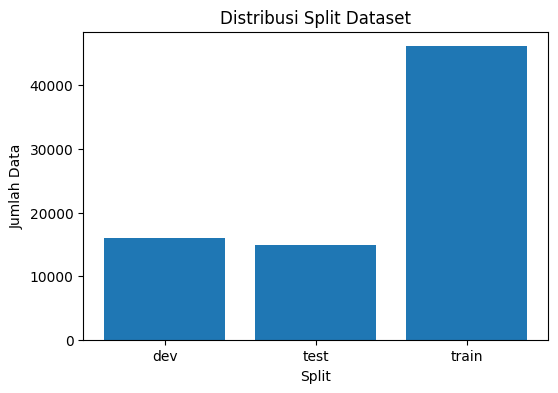

In [17]:
plt.figure(figsize=(6,4))
plt.bar(split_summary.index, split_summary["count"])
plt.title("Distribusi Split Dataset")
plt.xlabel("Split")
plt.ylabel("Jumlah Data")
plt.show()

Masih konsisten seperti hasl distribusi split dataset diatas, setelah downsampling sebagian besar data tetap berada pada split `train`, yaitu sebanyak 46131 data atau 60.00% dari total dataset. Sementara itu, split `dev` berisi 15920 data atau 20.71%, dan split `test` berisi 14834 data atau 19.29%. Proporsi ini dibuat agar ukuran data latih menjadi lebih ringan dan aman diproses saat tokenisasi maupun training, sambil tetap menyisakan data validasi dan pengujian dalam jumlah yang memadai untuk evaluasi model.

### Statistik panjang artikel dan summary per split

In [18]:
def count_words(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())

def count_chars(text):
    if pd.isna(text):
        return 0
    return len(str(text))

df_all["article_words"] = df_all["clean_article"].apply(count_words)
df_all["article_chars"] = df_all["clean_article"].apply(count_chars)

df_all["summary_words"] = df_all["clean_summary"].apply(count_words)
df_all["summary_chars"] = df_all["clean_summary"].apply(count_chars)

length_summary = (
    df_all.groupby("split")
    .agg(
        article_words_mean=("article_words", "mean"),
        article_words_median=("article_words", "median"),
        article_words_min=("article_words", "min"),
        article_words_max=("article_words", "max"),

        article_chars_mean=("article_chars", "mean"),
        article_chars_median=("article_chars", "median"),
        article_chars_min=("article_chars", "min"),
        article_chars_max=("article_chars", "max"),

        summary_words_mean=("summary_words", "mean"),
        summary_words_median=("summary_words", "median"),
        summary_words_min=("summary_words", "min"),
        summary_words_max=("summary_words", "max"),

        summary_chars_mean=("summary_chars", "mean"),
        summary_chars_median=("summary_chars", "median"),
        summary_chars_min=("summary_chars", "min"),
        summary_chars_max=("summary_chars", "max"),
    )
    .round(2)
)

display(length_summary)

,article_words_mean,article_words_median,article_words_min,article_words_max,article_chars_mean,article_chars_median,article_chars_min,article_chars_max,summary_words_mean,summary_words_median,summary_words_min,summary_words_max,summary_chars_mean,summary_chars_median,summary_chars_min,summary_chars_max
split,,,,,,,,,,,,,,,,
dev,229.15,199.0,78,1841,1455.56,1268.0,465,11524,24.56,25.0,12,42,162.33,165.0,69,258
test,222.60,192.0,74,3515,1403.34,1209.5,481,23124,26.01,26.0,15,41,173.21,175.0,96,257
train,234.22,197.0,35,3496,1450.92,1222.0,239,20565,30.98,30.0,12,99,198.03,196.0,61,525


### Visualisasi distribusi panjang artikel per split

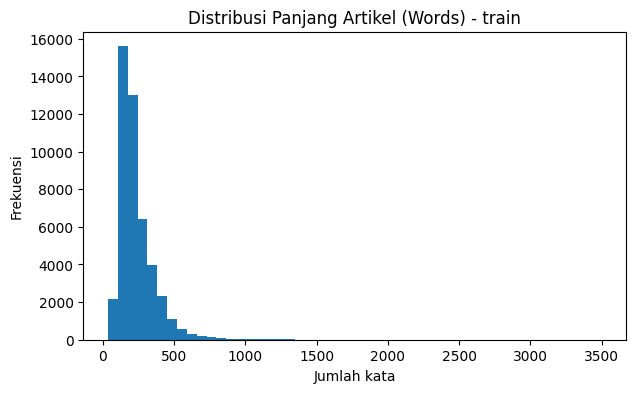

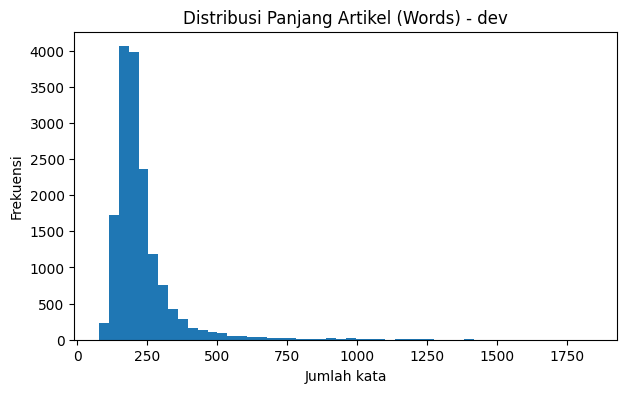

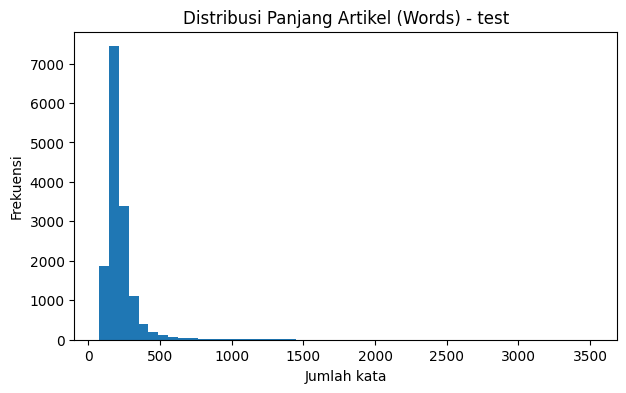

In [19]:
for split in ["train", "dev", "test"]:
    subset = df_all[df_all["split"] == split]

    plt.figure(figsize=(7, 4))
    plt.hist(subset["article_words"], bins=50)
    plt.title(f"Distribusi Panjang Artikel (Words) - {split}")
    plt.xlabel("Jumlah kata")
    plt.ylabel("Frekuensi")
    plt.show()

Distribusi panjang artikel pada seluruh split menunjukkan pola *right-skewed*, yaitu sebagian besar artikel memiliki panjang pada kisaran moderat, tetapi tetap terdapat sejumlah outlier yang sangat panjang. Hal ini terlihat dari nilai mean yang konsisten lebih besar daripada median pada semua split. Pada split `train`, rata-rata panjang artikel mencapai 234.22 kata dengan median 197 kata. Pada split `dev`, rata-ratanya 229.15 kata dengan median 199 kata, sedangkan pada split `test` rata-ratanya 222.60 kata dengan median 192 kata. Nilai maksimum juga jauh lebih tinggi dibanding mayoritas data, misalnya mencapai 3496 kata pada `train` dan 3515 kata pada `test`.

Sebaliknya, panjang `summary` jauh lebih pendek dan relatif stabil. Rata-rata panjang summary berada pada kisaran 24.56-30.98 kata, dengan median yang sangat dekat dengan mean pada seluruh split. Temuan ini menunjukkan bahwa target ringkasan cenderung singkat dan konsisten, sementara artikel sumber memiliki variasi panjang yang jauh lebih besar.

Secara umum, karakteristik ini sesuai untuk tugas summarization karena model perlu memilih informasi penting dari artikel yang lebih panjang untuk menghasilkan ringkasan yang jauh lebih singkat. Pada tahap modeling, input diproses pada level kalimat, sehingga panjang maksimum `128` token digunakan sebagai batas untuk setiap kalimat agar proses tokenisasi dan training tetap efisien dalam batas resource yang tersedia.

### Visualisasi distribusi panjang summary per split

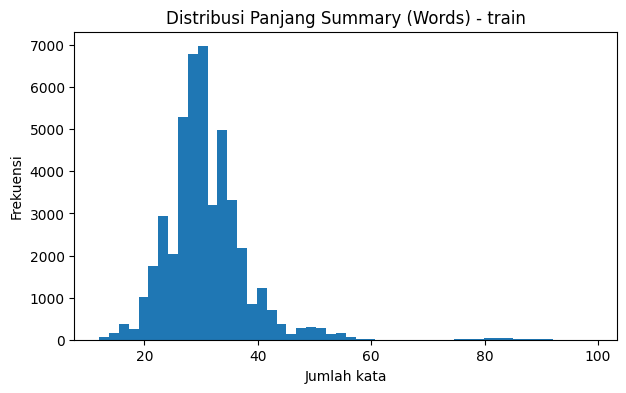

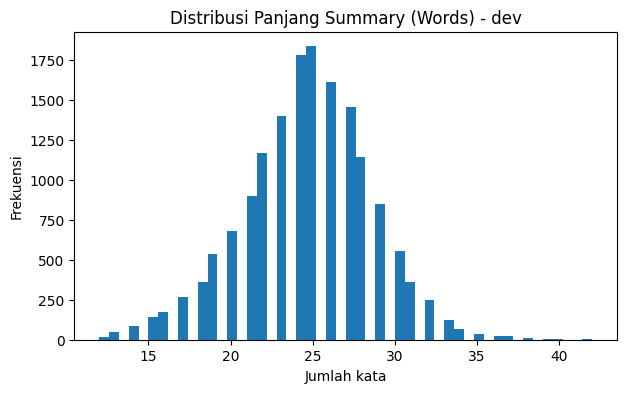

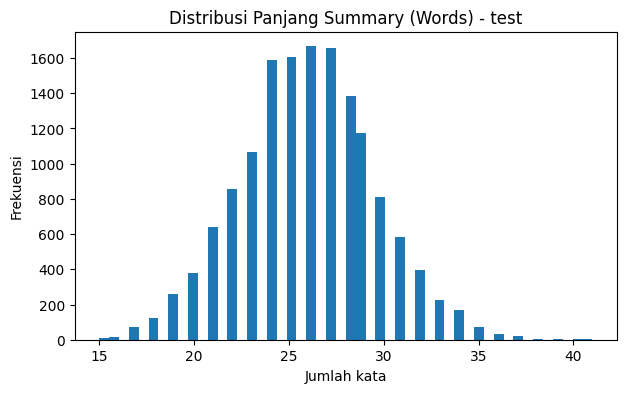

In [20]:
for split in ["train", "dev", "test"]:
    subset = df_all[df_all["split"] == split]

    plt.figure(figsize=(7, 4))
    plt.hist(subset["summary_words"], bins=50)
    plt.title(f"Distribusi Panjang Summary (Words) - {split}")
    plt.xlabel("Jumlah kata")
    plt.ylabel("Frekuensi")
    plt.show()

Distribusi panjang `summary` pada seluruh split terlihat jauh lebih sempit dan stabil dibandingkan panjang artikel. Sebagian besar summary terkonsentrasi pada kisaran sekitar 20-35 kata, dengan nilai mean dan median yang saling berdekatan pada semua split. Hal ini menunjukkan bahwa ringkasan dalam dataset memiliki panjang yang relatif konsisten dan tidak banyak bervariasi secara ekstrem, meskipun masih terdapat sedikit outlier, terutama pada split `train`.

Temuan ini memperlihatkan bahwa target ringkasan pada dataset Liputan6 cenderung singkat, padat, dan seragam. Karakter ini mendukung hasil analisis sebelumnya bahwa proses summarization pada dataset lebih berfokus pada pemilihan informasi inti dari artikel, bukan pada pembentukan ringkasan panjang dengan variasi struktur yang besar.

### Hitung compression ratio per split

In [21]:
df_all["compression_ratio_words"] = df_all["summary_words"] / df_all["article_words"]
df_all["compression_ratio_chars"] = df_all["summary_chars"] / df_all["article_chars"]

compression_summary = (
    df_all.groupby("split")
    .agg(
        compression_words_mean=("compression_ratio_words", "mean"),
        compression_words_median=("compression_ratio_words", "median"),
        compression_words_min=("compression_ratio_words", "min"),
        compression_words_max=("compression_ratio_words", "max"),

        compression_chars_mean=("compression_ratio_chars", "mean"),
        compression_chars_median=("compression_ratio_chars", "median"),
        compression_chars_min=("compression_ratio_chars", "min"),
        compression_chars_max=("compression_ratio_chars", "max"),
    )
    .round(4)
)

display(compression_summary)

,compression_words_mean,compression_words_median,compression_words_min,compression_words_max,compression_chars_mean,compression_chars_median,compression_chars_min,compression_chars_max
split,,,,,,,,
dev,0.1225,0.1203,0.0149,0.3974,0.1277,0.1260,0.0153,0.3656
test,0.1351,0.1338,0.0083,0.3271,0.1429,0.1416,0.0077,0.3407
train,0.1632,0.1469,0.0092,1.0405,0.1691,0.1527,0.0104,1.0134


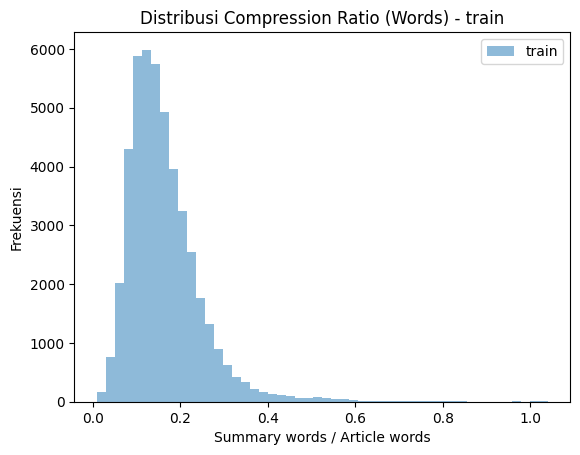

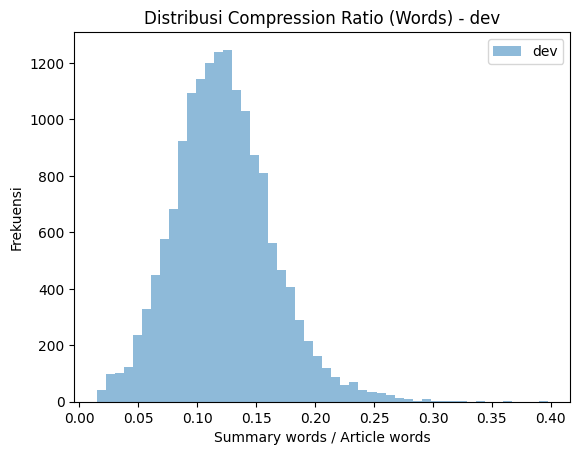

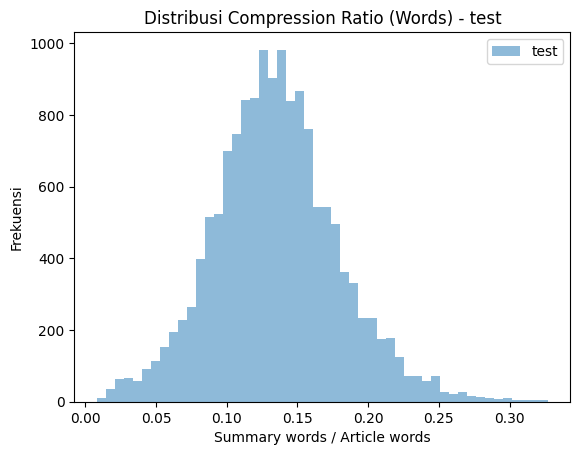

In [22]:
for split in ["train", "dev", "test"]:
    subset = df_all[df_all["split"] == split]

    plt.title(f"Distribusi Compression Ratio (Words) - {split}")
    plt.hist(subset["compression_ratio_words"], bins=50, alpha=0.5, label=split)
    plt.xlabel("Summary words / Article words")
    plt.ylabel("Frekuensi")
    plt.legend()
    plt.show()

Distribusi *compression ratio* menunjukkan bahwa `summary` pada dataset ini umumnya hanya sekitar 12% sampai 16% dari panjang artikel asli. Nilai mean dan median pada ketiga split juga relatif berdekatan, sehingga tingkat kompresi dataset dapat dikatakan cukup stabil. Hal ini menunjukkan bahwa tugas summarization pada dataset Liputan6 memang menuntut peringkasan yang cukup kuat, karena artikel yang relatif panjang perlu diringkas menjadi keluaran yang jauh lebih singkat.

Dari sisi karakter data, compression ratio yang rendah seperti ini dapat menjadi sinyal awal bahwa pendekatan abstractive berpotensi relevan, karena model perlu menghasilkan ringkasan yang sangat padat. Namun, compression ratio saja belum cukup untuk menentukan pendekatan akhir. Analisis tetap perlu dilanjutkan dengan melihat lexical overlap antara artikel dan summary. Jika overlap-nya tinggi, maka pendekatan extractive masih sangat mungkin lebih sesuai meskipun tingkat kompresinya cukup besar.

### Helper function tokenisasi sederhana

In [23]:
stop_words = set(stopwords.words("indonesian"))

def simple_tokenize(text):
    if pd.isna(text):
        return []

    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9À-ÿ؀-ۿ\u00C0-\u024F\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()

    # buang stopwords
    tokens = [tok for tok in tokens if tok not in stop_words]

    return tokens

def get_ngrams(tokens, n=1):
    return zip(*[tokens[i:] for i in range(n)])

Next kita buat fungsi ini digunakan untuk tokenisasi sederhana dan pembentukan n-gram agar kosakata yang sering muncul dapat dianalisis.

### Lexical overlap / source overlap

In [24]:
def calc_source_overlap(article, summary):
    article_tokens = simple_tokenize(article)
    summary_tokens = simple_tokenize(summary)

    if len(article_tokens) == 0 or len(summary_tokens) == 0:
        return pd.Series({
            "overlap_token_ratio": 0.0,
            "overlap_unique_ratio": 0.0,
            "jaccard_similarity": 0.0
        })

    article_token_set = set(article_tokens)
    summary_token_set = set(summary_tokens)

    overlap_token_ratio = sum(tok in article_token_set for tok in summary_tokens) / len(summary_tokens)
    overlap_unique_ratio = len(summary_token_set & article_token_set) / len(summary_token_set)
    jaccard_similarity = len(summary_token_set & article_token_set) / len(summary_token_set | article_token_set)

    return pd.Series({
        "overlap_token_ratio": overlap_token_ratio,
        "overlap_unique_ratio": overlap_unique_ratio,
        "jaccard_similarity": jaccard_similarity
    })

overlap_features = df_all.apply(
    lambda row: calc_source_overlap(row["clean_article"], row["clean_summary"]),
    axis=1
)

df_all = pd.concat([df_all, overlap_features], axis=1)

Bagian ini menghitung lexical overlap antara artikel dan summary. `overlap_token_ratio` mengukur proporsi token summary yang juga muncul di artikel, `overlap_unique_ratio` mengukur proporsi kata unik summary yang ada di artikel, dan `jaccard_similarity` mengukur tingkat kemiripan himpunan kata unik antara artikel dan summary. Hasilnya kemudian ditambahkan ke `df_all` untuk analisis lebih lanjut.

In [25]:
overlap_summary = (
    df_all.groupby("split")
    .agg(
        overlap_token_mean=("overlap_token_ratio", "mean"),
        overlap_token_median=("overlap_token_ratio", "median"),
        overlap_token_min=("overlap_token_ratio", "min"),
        overlap_token_max=("overlap_token_ratio", "max"),

        overlap_unique_mean=("overlap_unique_ratio", "mean"),
        overlap_unique_median=("overlap_unique_ratio", "median"),
        overlap_unique_min=("overlap_unique_ratio", "min"),
        overlap_unique_max=("overlap_unique_ratio", "max"),

        jaccard_mean=("jaccard_similarity", "mean"),
        jaccard_median=("jaccard_similarity", "median"),
        jaccard_min=("jaccard_similarity", "min"),
        jaccard_max=("jaccard_similarity", "max"),
    )
    .round(4)
)

display(overlap_summary)

,overlap_token_mean,overlap_token_median,overlap_token_min,overlap_token_max,overlap_unique_mean,overlap_unique_median,overlap_unique_min,overlap_unique_max,jaccard_mean,jaccard_median,jaccard_min,jaccard_max
split,,,,,,,,,,,,
dev,0.7920,0.8095,0.2222,1.0,0.7822,0.8000,0.2222,1.0,0.1319,0.1279,0.0124,0.3947
test,0.8180,0.8333,0.3077,1.0,0.8076,0.8235,0.2143,1.0,0.1513,0.1481,0.0080,0.4444
train,0.8667,0.8929,0.0625,1.0,0.8588,0.8824,0.0625,1.0,0.1868,0.1695,0.0116,1.0000


Hasil *lexical overlap* menunjukkan bahwa `summary` memiliki kedekatan leksikal yang tinggi dengan artikel sumber. Nilai `overlap_token_ratio` berada pada kisaran `0.79-0.87`, sedangkan `overlap_unique_ratio` berada pada kisaran `0.78-0.86`. Sementara itu, `jaccard_similarity` relatif lebih rendah, sekitar `0.13-0.19`, yang masih wajar karena artikel jauh lebih panjang dibanding summary.

Jika dikaitkan dengan hasil *compression ratio* sebelumnya, temuan ini menunjukkan bahwa meskipun ringkasan pada dataset ini sangat singkat, pilihan katanya masih banyak berasal dari artikel asli. Artinya, dataset memang menuntut kompresi informasi yang kuat, tetapi secara leksikal tetap dekat dengan sumber.

Karena itu, dataset Liputan6 lebih tepat diposisikan sebagai **extractive-friendly summarization**. Oleh sebab itu, pendekatan **extractive summarization** dipilih sebagai pendekatan yang lebih aman dan sesuai untuk eksperimen utama.

### Top unigram pada artikel (train)

In [26]:
article_tokens_train = list(chain.from_iterable(
    df_train["clean_article"].apply(simple_tokenize)
))

top20_unigram_article = pd.DataFrame(
    Counter(article_tokens_train).most_common(20),
    columns=["unigram", "freq"]
)

display(top20_unigram_article)

,unigram,freq
0,com,41087
1,liputan6,40519
2,jakarta,39842
3,warga,30056
4,tim,26639
5,rumah,22832
6,baca,21849
7,polisi,19640
8,indonesia,19346
9,rp,18023


### Top bigram pada artikel (train)

In [27]:
article_bigrams_train = Counter(
    chain.from_iterable(
        get_ngrams(tokens, 2)
        for tokens in df_train["clean_article"].apply(simple_tokenize)
    )
)

top20_bigram_article = pd.DataFrame(
    [(" ".join(bg), freq) for bg, freq in article_bigrams_train.most_common(20)],
    columns=["bigram", "freq"]
)

display(top20_bigram_article)

,bigram,freq
0,liputan6 com,40359
1,com jakarta,15163
2,liputan 6,9258
3,6 sctv,8736
4,tim liputan,8525
5,rumah sakit,6441
6,jawa barat,5504
7,jawa timur,4733
8,jakarta pusat,3137
9,anak anak,3004


Hasil analisis unigram dan bigram menunjukkan bahwa setelah filtering dengan NLTK stopwords, kata-kata umum sudah banyak berkurang. Namun, masih terlihat token boilerplate khas media seperti `liputan6`, `com`, `liputan`, `sctv`, `baca`, serta format waktu seperti `wib` dan `00`. Token-token ini lebih merefleksikan identitas media atau template penulisan berita daripada isi semantik utama artikel, sehingga layak dipertimbangkan sebagai domain stopwords.

Berdasarkan temuan tersebut, beberapa domain stopwords yang dipilih adalah:

```python
domain_stopwords = {"liputan6", "com", "liputan", "sctv", "baca", "00", "wib"}

### Top unigram pada summary (train)

In [28]:
summary_tokens_train = list(chain.from_iterable(
    df_train["clean_summary"].apply(simple_tokenize)
))

top20_unigram_summary = pd.DataFrame(
    Counter(summary_tokens_train).most_common(20),
    columns=["unigram", "freq"]
)

display(top20_unigram_summary)

,unigram,freq
0,warga,5673
1,jakarta,3697
2,rumah,3604
3,korban,3312
4,indonesia,3168
5,polisi,2957
6,pemerintah,2890
7,presiden,2665
8,orang,2660
9,kota,2537


### Top bigram pada summary (train)

In [29]:
summary_bigrams_train = Counter(
    chain.from_iterable(
        get_ngrams(tokens, 2)
        for tokens in df_train["clean_summary"].apply(simple_tokenize)
    )
)

top20_bigram_summary = pd.DataFrame(
    [(" ".join(bg), freq) for bg, freq in summary_bigrams_train.most_common(20)],
    columns=["bigram", "freq"]
)

display(top20_bigram_summary)

,bigram,freq
0,rumah sakit,749
1,jawa barat,734
2,jawa timur,609
3,manchester united,481
4,minyak tanah,436
5,real madrid,419
6,anak anak,418
7,amerika serikat,411
8,1 0,411
9,jakarta selatan,401


Pada `summary`, hasil unigram dan bigram terlihat jauh lebih bersih dibandingkan artikel. Token boilerplate media seperti `liputan6`, `com`, atau `sctv` tidak lagi dominan, sehingga kata-kata yang paling sering muncul lebih merepresentasikan isi topik berita. Dengan demikian, token-token pada summary dipertahankan karena masih informatif dan relevan terhadap konten ringkasan.

### Jumlah kalimat artikel dan summary per split

In [30]:
def count_sentences(text):
    if pd.isna(text):
        return 0
    text = str(text).strip()
    if not text:
        return 0
    return len([s for s in re.split(r"[.!?]+", text) if s.strip()])

df_all["article_sentences"] = df_all["clean_article"].apply(count_sentences)
df_all["summary_sentences"] = df_all["clean_summary"].apply(count_sentences)

sentence_summary = (
    df_all.groupby("split")
    .agg(
        article_sent_mean=("article_sentences", "mean"),
        article_sent_median=("article_sentences", "median"),
        article_sent_min=("article_sentences", "min"),
        article_sent_max=("article_sentences", "max"),

        summary_sent_mean=("summary_sentences", "mean"),
        summary_sent_median=("summary_sentences", "median"),
        summary_sent_min=("summary_sentences", "min"),
        summary_sent_max=("summary_sentences", "max"),
    )
    .round(2)
)

display(sentence_summary)

,article_sent_mean,article_sent_median,article_sent_min,article_sent_max,summary_sent_mean,summary_sent_median,summary_sent_min,summary_sent_max
split,,,,,,,,
dev,15.00,13.0,4,122,2.05,2.0,1,7
test,14.43,12.0,5,197,2.09,2.0,1,6
train,15.15,13.0,2,308,2.14,2.0,1,11


Statistik jumlah kalimat menunjukkan bahwa artikel dalam dataset rata-rata terdiri dari sekitar `14-15` kalimat, sedangkan `summary` hanya sekitar `2` kalimat. Median artikel berada pada kisaran `12-13` kalimat, sementara median summary konsisten di `2` kalimat pada seluruh split. Temuan ini menegaskan bahwa dataset Liputan6 memang dirancang untuk merangkum beberapa kalimat penting dari artikel menjadi ringkasan yang sangat singkat dan padat.

### Jumlah kalimat extractive yang dipilih per split

In [31]:
def count_extractive_sentences(x):
    if isinstance(x, list):
        return len(x)
    return 0

df_all["extractive_sent_count"] = df_all["extractive_summary"].apply(count_extractive_sentences)

extractive_summary_stats = (
    df_all.groupby("split")
    .agg(
        extractive_sent_mean=("extractive_sent_count", "mean"),
        extractive_sent_median=("extractive_sent_count", "median"),
        extractive_sent_min=("extractive_sent_count", "min"),
        extractive_sent_max=("extractive_sent_count", "max"),
    )
    .round(2)
)

display(extractive_summary_stats)

,extractive_sent_mean,extractive_sent_median,extractive_sent_min,extractive_sent_max
split,,,,
dev,2.11,2.0,2,7
test,2.11,2.0,2,5
train,2.26,2.0,2,11


Jumlah kalimat pada ringkasan ekstraktif rata-rata berada di kisaran `2.11-2.26` kalimat, dengan median yang konsisten di angka `2` pada semua split. Hal ini menunjukkan bahwa sebagian besar ringkasan ekstraktif dalam dataset dibentuk dari sangat sedikit kalimat sumber, sehingga pendekatan extractive memang cukup sesuai untuk mewakili informasi utama artikel.

### Ringkasan fokus untuk menentukan extractive vs abstractive

In [32]:
decision_summary = pd.concat(
    [
        compression_summary[["compression_words_mean", "compression_words_median"]],
        overlap_summary[["overlap_token_mean", "overlap_unique_mean", "jaccard_mean"]],
        extractive_summary_stats[["extractive_sent_mean", "extractive_sent_median"]],
    ],
    axis=1
).round(4)

display(decision_summary)

,compression_words_mean,compression_words_median,overlap_token_mean,overlap_unique_mean,jaccard_mean,extractive_sent_mean,extractive_sent_median
split,,,,,,,
dev,0.1225,0.1203,0.7920,0.7822,0.1319,2.11,2.0
test,0.1351,0.1338,0.8180,0.8076,0.1513,2.11,2.0
train,0.1632,0.1469,0.8667,0.8588,0.1868,2.26,2.0


Berdasarkan hasil EDA, dataset ini lebih tepat diposisikan sebagai **extractive summarization**. Meskipun *compression ratio* cukup kecil, *lexical overlap* antara artikel dan `summary` tetap tinggi, dan jumlah kalimat pada `extractive_summary` juga konsisten di sekitar 2 kalimat. Hal ini menunjukkan bahwa ringkasan cenderung singkat, tetapi masih dekat secara leksikal dengan artikel sumber dan umumnya dapat diwakili oleh sedikit kalimat penting.

Untuk eksperimen utama, dipilih dua model yang sama-sama sesuai untuk bahasa Indonesia, yaitu **IndoBERT** dan **Indonesian RoBERTa**. `IndoBERT` (`indobenchmark/indobert-base-p2`) digunakan sebagai model utama, sedangkan `Indonesian RoBERTa` (`cahya/roberta-base-indonesian-522M`) digunakan sebagai pembanding. Dengan demikian, perbandingan tetap relevan untuk dataset berbahasa Indonesia sekaligus memungkinkan analisis pengaruh perbedaan arsitektur **BERT** dan **RoBERTa** pada tugas extractive summarization.

**Notes:** Pada pelaksanaan eksperimen, model pembanding **Indonesian RoBERTa** belum sempat dijalankan karena keterbatasan waktu dan resource. Oleh karena itu, eksperimen pada model ini belum dimasukkan ke hasil utama dan akan ditempatkan sebagai bagian dari **future work** untuk pengembangan selanjutnya.

## Preprocessing

### Import Library

In [33]:
import re
import ast
import pandas as pd
import numpy as np
from transformers import AutoTokenizer

Import library untuk proses preprocessing, meliputi pembersihan teks, parsing label ekstraktif, serta tokenisasi menggunakan *pretrained tokenizer*.

### Konfigurasi processing

In [34]:
MAX_LEN_SENT = 128   # untuk sentence-level modeling, mulai dari 128 

domain_stopwords_model = {
    "liputan6", "com", "liputan", "sctv", "baca", "00", "wib"
}

MODEL_1 = "indobenchmark/indobert-base-p2"
MODEL_2 = "cahya/roberta-base-indonesian-522M"

Selanjutnya, ditentukan parameter utama untuk tahap preprocessing. Panjang maksimum input ditetapkan sebesar `128` token untuk setiap kalimat (`sentence-level modeling`) agar proses tokenisasi dan training tetap efisien. Domain stopwords untuk model juga ditetapkan secara lebih konservatif berdasarkan hasil EDA, sehingga token boilerplate khas media dapat dikurangi tanpa terlalu banyak menghapus kata yang masih berpotensi informatif.

### Load Tokenizer kedua model

In [35]:
tokenizer_indobert = AutoTokenizer.from_pretrained(MODEL_1)
tokenizer_roberta = AutoTokenizer.from_pretrained(MODEL_2)

Selanjutnya, dimuat *pretrained tokenizer* dari dua model yang dipilih, yaitu **IndoBERT** dan **Indonesian RoBERTa**. Tokenizer ini digunakan untuk mengubah teks menjadi token sesuai format masukan masing-masing model pada tahap preprocessing dan modeling.

### Helper function dasar

In [36]:
LEAD_NEWS_PAT = re.compile(
    r"^\s*liputan\s*6(?:\s*\.?\s*com)?(?:\s*[^\w\s]+\s*)*jakarta(?:\s*[^\w\s]+\s*)*",
    flags=re.IGNORECASE
)

PURE_BOILERPLATE_PAT = re.compile(
    r"^\s*(?:liputan\s*6(?:\s*\.?\s*com)?|jakarta|[^\w\s])+\s*$",
    flags=re.IGNORECASE
)


def normalize_ws(text):
    if pd.isna(text):
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()


def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            val = ast.literal_eval(x)
            if isinstance(val, list):
                return val
        except Exception:
            return []
    return []


def remove_urls(text):
    text = normalize_ws(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text, flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", text).strip()


def clean_light_punctuation(text):
    text = normalize_ws(text)

    # rapikan spasi sebelum tanda baca
    text = re.sub(r"\s+([.,:;!?])", r"\1", text)

    # rapikan kurung
    text = re.sub(r"([\(\[\{])\s+", r"\1", text)
    text = re.sub(r"\s+([\)\]\}])", r"\1", text)

    # rapikan pola huruf inisial
    text = re.sub(r"\b([a-z])\s*\.\s*([a-z])\b", r"\1. \2", text, flags=re.IGNORECASE)

    # hilangkan deret punctuation token berdiri sendiri
    text = re.sub(r"(?:\s[.,:;!?]\s?){2,}", " ", text)

    # hilangkan punctuation tunggal yang terpisah
    text = re.sub(r"(?<=\s)[.,:;!?](?=\s)", " ", text)

    return re.sub(r"\s+", " ", text).strip()


def split_sentences_fallback(text):
    text = normalize_ws(text)
    if not text:
        return []

    # split hanya jika setelah tanda akhir kalimat benar-benar mulai kalimat baru
    sents = re.split(r"(?<=[.!?])\s+(?=[A-Za-z0-9\"'(\[])", text)
    sents = [s.strip() for s in sents if s.strip()]
    return sents

Pada tahap ini, disiapkan pola regex dan fungsi dasar untuk preprocessing teks. `LEAD_NEWS_PAT` digunakan untuk mengenali lead berita seperti `Liputan6.com, Jakarta` yang umumnya bersifat boilerplate, sedangkan `PURE_BOILERPLATE_PAT` digunakan untuk mendeteksi fragmen yang hanya berisi boilerplate murni tanpa informasi isi.

Fungsi utilitas lain juga disiapkan untuk merapikan spasi berlebih, memastikan data label ekstraktif berada dalam format list, menghapus URL, merapikan tanda baca ringan, dan memecah teks menjadi kalimat menggunakan aturan regex sederhana jika pemisahan kalimat utama tidak tersedia. Dengan preprocessing ini, teks menjadi lebih konsisten dan noise khas berita online dapat dikurangi sebelum masuk ke tahap modeling.

### Cleaner artikel & Summary

In [37]:
def remove_domain_boilerplate(text, stopwords_set=domain_stopwords_model, do_lower=True):
    text = normalize_ws(text)
    text = remove_urls(text)

    if do_lower:
        text = text.lower()

    text = clean_light_punctuation(text)

    # hapus lead jika masih muncul di awal sentence
    text = LEAD_NEWS_PAT.sub("", text)

    boilerplate_patterns = [
        r"\bliputan6\s*\.?\s*com\b",
        r"\bliputan\s*6\b",
        r"\b6\s+sctv\b",
        r"\btim\s+liputan\b",
        r"\bbaca\s+juga\b",
        r"\bsimak\s+juga\b",
        r"\blihat\s+juga\b",
        r"\bselengkapnya\b",
        r"\b00\s*wib\b",
    ]

    for pat in boilerplate_patterns:
        text = re.sub(pat, " ", text, flags=re.IGNORECASE)

    if stopwords_set:
        pattern = r"\b(?:%s)\b" % "|".join(
            map(re.escape, sorted(stopwords_set, key=len, reverse=True))
        )
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)

    return re.sub(r"\s+", " ", text).strip()


def clean_article_sentence(sent, do_lower=True):
    sent = normalize_ws(sent)

    sent_clean = remove_domain_boilerplate(
        sent,
        stopwords_set=domain_stopwords_model,
        do_lower=do_lower
    )

    # kalau hasilnya kosong / cuma simbol dan aslinya boilerplate, buang
    if not sent_clean or not re.search(r"[a-z0-9]", sent_clean):
        if PURE_BOILERPLATE_PAT.match(sent) or sent_clean in {"", ".", ",", ":", ";", "-", "--"}:
            return ""
        return sent.lower().strip() if do_lower else sent.strip()

    return sent_clean


def clean_summary_text(text, do_lower=True):
    text = normalize_ws(text)
    text = remove_urls(text)

    if do_lower:
        text = text.lower()

    text = clean_light_punctuation(text)
    return re.sub(r"\s+", " ", text).strip()

Next, dilakukan pembersihan utama pada artikel dan summary. Fungsi `remove_domain_boilerplate()` digunakan untuk menghapus URL, lead berita, boilerplate media, dan domain stopwords yang teridentifikasi dari EDA. Setelah itu, `clean_article_sentence()` digunakan untuk membersihkan setiap kalimat artikel. Jika setelah dibersihkan sebuah kalimat hanya menyisakan boilerplate murni atau simbol tanpa isi semantik, kalimat tersebut dibuang, sedangkan untuk `summary`, digunakan fungsi `clean_summary_text()` yang lebih ringan. Pembersihan difokuskan pada normalisasi spasi, penghapusan URL, lowercasing, dan perapihan tanda baca, tanpa menghapus terlalu banyak token agar isi ringkasan tetap terjaga.

### Preprocess per DataFrame

In [38]:
def preprocess_extractive_df_sentence_level(df):
    out = df.copy()

    def _prepare_article_for_split(text):
        text = normalize_ws(text)
        text = remove_urls(text)
        text = text.lower()

        # cegah false split seperti ". ," atau ". :"
        text = re.sub(r"\s*\.\s*(?=[,;:])", "", text)

        text = clean_light_punctuation(text)
        text = LEAD_NEWS_PAT.sub("", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def _sanitize_extractive_indices(lst, n_sent):
        clean_idx = []
        for x in lst:
            try:
                i = int(x)
                if 0 <= i < n_sent:
                    clean_idx.append(i)
            except Exception:
                pass
        return sorted(set(clean_idx))

    def _clean_sentences_keep_alignment(sents_raw, positive_idx):
        """
        Cleaning per kalimat TANPA mengubah panjang list,
        supaya alignment index extractive_summary tetap aman.
        Kalau kalimat positif kosong setelah cleaning,
        fallback ke versi raw yang dibersihkan ringan.
        """
        pos_set = set(positive_idx)
        cleaned = []

        for i, sent in enumerate(sents_raw):
            sent_clean = clean_article_sentence(sent, do_lower=True)

            if normalize_ws(sent_clean):
                cleaned.append(sent_clean)
            else:
                if i in pos_set:
                    # positive sentence jangan sampai hilang
                    fallback = normalize_ws(sent).lower()
                    fallback = remove_urls(fallback)
                    fallback = clean_light_punctuation(fallback)
                    cleaned.append(
                        fallback if normalize_ws(fallback) else normalize_ws(sent).lower()
                    )
                else:
                    cleaned.append("")

        return cleaned

    def _compress_for_model(sents_aligned, labels_aligned):
        """
        Buang kalimat kosong setelah cleaning.
        Positive sentence tetap aman karena sebelumnya sudah difallback.
        """
        new_sents = []
        new_labels = []
        new_positive_idx = []

        for sent, lab in zip(sents_aligned, labels_aligned):
            sent = normalize_ws(sent)
            if sent:
                new_idx = len(new_sents)
                new_sents.append(sent)
                new_labels.append(int(lab))
                if int(lab) == 1:
                    new_positive_idx.append(new_idx)

        return new_sents, new_labels, new_positive_idx

    # amankan kolom
    out["clean_article"] = out["clean_article"].fillna("").astype(str)
    out["clean_summary"] = out["clean_summary"].fillna("").astype(str)
    out["extractive_summary"] = out["extractive_summary"].apply(ensure_list)

    # prepare article -> split raw sentence
    out["article_for_split"] = out["clean_article"].apply(_prepare_article_for_split)
    out["article_sentences_raw"] = out["article_for_split"].apply(split_sentences_fallback)
    out["n_sentences_raw"] = out["article_sentences_raw"].apply(len)

    # buang artikel kosong
    out = out[out["n_sentences_raw"] > 0].copy()

    # validasi gold index terhadap raw split
    out["extractive_summary"] = out.apply(
        lambda row: _sanitize_extractive_indices(row["extractive_summary"], row["n_sentences_raw"]),
        axis=1
    )

    # buang artikel tanpa label positif
    out = out[out["extractive_summary"].apply(len) > 0].copy()

    # cleaning per sentence, alignment tetap aman
    out["article_sentences_clean_aligned"] = out.apply(
        lambda row: _clean_sentences_keep_alignment(
            row["article_sentences_raw"],
            row["extractive_summary"]
        ),
        axis=1
    )

    # label aligned berdasarkan raw sentence index
    out["sentence_labels_aligned"] = out.apply(
        lambda row: [1 if i in set(row["extractive_summary"]) else 0 for i in range(row["n_sentences_raw"])],
        axis=1
    )

    # kompres untuk model-ready
    compressed = out.apply(
        lambda row: _compress_for_model(
            row["article_sentences_clean_aligned"],
            row["sentence_labels_aligned"]
        ),
        axis=1
    )

    out["article_sentences_model"] = compressed.apply(lambda x: x[0])
    out["sentence_labels_model"] = compressed.apply(lambda x: x[1])
    out["extractive_summary_model"] = compressed.apply(lambda x: x[2])
    out["n_sentences_model"] = out["article_sentences_model"].apply(len)

    # final processed text
    out["article_text_proc"] = out["article_sentences_model"].apply(lambda sents: " ".join(sents).strip())
    out["summary_text_proc"] = out["clean_summary"].apply(lambda x: clean_summary_text(x, do_lower=True))

    # filtering final
    out = out[out["article_text_proc"].str.len() > 0].copy()
    out = out[out["summary_text_proc"].str.len() > 0].copy()
    out = out[out["n_sentences_model"] > 0].copy()
    out = out[out["extractive_summary_model"].apply(len) > 0].copy()

    # sanity guard
    out = out[
        out.apply(
            lambda row: len(row["article_sentences_model"]) == len(row["sentence_labels_model"]),
            axis=1
        )
    ].copy()

    return out.reset_index(drop=True)

Fungsi `preprocess_extractive_df_sentence_level()` digunakan untuk menyiapkan data ke format *sentence-level extractive summarization*. Artikel terlebih dahulu dinormalisasi, dibersihkan ringan, lalu dipecah menjadi kalimat. Selanjutnya, indeks pada `extractive_summary` divalidasi agar tetap sesuai dengan jumlah kalimat hasil split. Dari indeks ini kemudian dibentuk label biner per kalimat, yaitu `1` untuk kalimat yang termasuk ringkasan ekstraktif dan `0` untuk kalimat yang tidak terpilih.

Setelah itu, setiap kalimat dibersihkan satu per satu tanpa mengubah alignment dengan label ekstraktif. Jika kalimat positif menjadi kosong setelah cleaning, digunakan versi *fallback* agar informasi penting tidak hilang. Kalimat kosong non-informatif kemudian dibuang, lalu dibentuk kembali kalimat siap model, label akhir per kalimat, teks artikel akhir, dan summary yang sudah dibersihkan.

Di bagian akhir, dilakukan filtering dan *sanity check* untuk memastikan jumlah kalimat, label, artikel, dan summary tetap valid. Dengan demikian, output preprocessing ini sudah konsisten dan siap digunakan pada tahap tokenisasi serta modeling. 

### Terapkan ke train/dev/test

In [39]:
train_proc = preprocess_extractive_df_sentence_level(df_train)
dev_proc   = preprocess_extractive_df_sentence_level(df_dev)
test_proc  = preprocess_extractive_df_sentence_level(df_test)

print("Processed shapes:")
print(train_proc.shape, dev_proc.shape, test_proc.shape)

display(train_proc[[
    "id",
    "article_text_proc",
    "summary_text_proc",
    "extractive_summary_model",
    "n_sentences_model",
    "sentence_labels_model"
]].head())

Processed shapes:
(46131, 18) (15920, 18) (14834, 18)


,id,article_text_proc,summary_text_proc,extractive_summary_model,n_sentences_model,sentence_labels_model
0,239502,"dua anggota tim komite nasional keselamatan transportasi (knkt) pada rabu (5/8) pagi, berangkat dari jakarta menuju oksibil, kabupaten pegunungan ...","komite nasional keselamatan transportasi berangkat menuju oksibi, papua, untuk menyelidiki penyebab jatuhnya pesawat merpati.","[0, 1]",11,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
1,215354,"posisi puncak klasemen masih diduduki liverpool. mereka unggul empat poin dari chelsea di urutan kedua, dan lima poin dari manchester united. namu...",fernando torres mengeluarkan pendapat mengenai persaingan ketat liverpool dan manchester united di liga premier. torres tanpa sungkan percaya kala...,"[1, 3, 7, 10]",18,"[0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]"
2,295725,"hari raya idulfitri biasanya dirayakan bersama keluarga atau sanak saudara. namun, ternyata tidak semua orang bisa merasakan itu. seorang di antar...","penjaga palang pintu perlintasan kereta tetap bekerja saat lebaran. mereka harus berada di ruang 3x4 meter hanya ditemani radio, kipas angin, dan ...","[3, 7]",16,"[0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
3,222639,"lama tak terdengar, penyanyi anggun c. sasmi yang selama ini menetap di prancis, tiba-tiba sudah ada di tanah air. selain kangen kampung halaman, ...","lama tak terdengar, penyanyi anggun c. sasmi yang selama ini menetap di prancis, tiba-tiba sudah ada di tanah air. selain kangen kampung halaman, ...","[0, 1, 2, 3]",12,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]"
4,124497,"pemerintah dki jakarta menggelar jakarta great sale selama satu bulan sejak 14 juni hingga 14 juli 2006. kali ini, pesta diskon tak hanya diberika...",pemerintah dki jakarta menggelar program potongan harga sepuluh persen khusus pemeriksaan rontgen dan ct scan. program diskon ini tidak berlaku un...,"[5, 6]",9,"[0, 0, 0, 0, 0, 1, 1, 0, 0]"


Setelah fungsi preprocessing diterapkan, diperoleh data hasil akhir sebanyak `46131` baris pada `train`, `15920` baris pada `dev`, dan `14834` baris pada `test`. Hasil ini menunjukkan bahwa seluruh split berhasil diproses dengan baik ke format *sentence-level* yang siap digunakan untuk tahap modeling.

Contoh output juga menunjukkan bahwa setiap data kini telah memiliki komponen utama yang dibutuhkan, yaitu `article_text_proc`, `summary_text_proc`, `extractive_summary_model`, `n_sentences_model`, dan `sentence_labels_model`. Hasil preprocessing sudah terbentuk dengan benar. Dengan demikian, setiap artikel sudah berhasil direpresentasikan ke dalam kalimat-kalimat yang bersih beserta label biner per kalimat untuk tugas extractive summarization.

### Flatten ke level kalimat

In [41]:
def build_sentence_level_df(df_proc, split_name):
    rows = []

    for _, row in df_proc.iterrows():
        article_id = row["id"]
        sentences = row["article_sentences_model"]
        labels = row["sentence_labels_model"]
        ref_summary = row["summary_text_proc"]
        gold_k = int(sum(labels))

        for sent_idx, (sent, lab) in enumerate(zip(sentences, labels)):
            rows.append({
                "id": article_id,
                "split": split_name,
                "sent_idx": sent_idx,
                "sentence_text": sent,
                "label": int(lab),
                "gold_k": gold_k,
                "reference_summary": ref_summary
            })

    return pd.DataFrame(rows).reset_index(drop=True)

Selanjutnya, dibuat fungsi `build_sentence_level_df()` untuk mengubah data hasil preprocessing menjadi format *sentence-level dataset*. Pada format ini, setiap kalimat dari artikel direpresentasikan sebagai satu baris data tersendiri, lengkap dengan informasi `id` artikel, nama `split`, indeks kalimat (`sent_idx`), isi kalimat (`sentence_text`), label biner (`label`), jumlah kalimat positif (`gold_k`), dan `reference_summary`.

Dengan format ini, proses modeling dapat dilakukan pada level kalimat, sehingga setiap kalimat dapat dipelajari sebagai kandidat apakah termasuk ke dalam ringkasan ekstraktif atau tidak.

In [42]:
train_sent_df = build_sentence_level_df(train_proc, "train")
dev_sent_df   = build_sentence_level_df(dev_proc, "dev")
test_sent_df  = build_sentence_level_df(test_proc, "test")

print("Sentence-level shapes:")
print(train_sent_df.shape, dev_sent_df.shape, test_sent_df.shape)

display(train_sent_df.head())

print("\nTrain label distribution:")
print(train_sent_df["label"].value_counts())
print(train_sent_df["label"].value_counts(normalize=True))

Sentence-level shapes:
(659206, 7) (224227, 7) (200893, 7)


,id,split,sent_idx,sentence_text,label,gold_k,reference_summary
0,239502,train,0,"dua anggota tim komite nasional keselamatan transportasi (knkt) pada rabu (5/8) pagi, berangkat dari jakarta menuju oksibil, kabupaten pegunungan ...",1,2,"komite nasional keselamatan transportasi berangkat menuju oksibi, papua, untuk menyelidiki penyebab jatuhnya pesawat merpati."
1,239502,train,1,mereka akan diterjunkan ke lokasi jatuhnya pesawat merpati untuk menyelidiki penyebab kecelakaan.,1,2,"komite nasional keselamatan transportasi berangkat menuju oksibi, papua, untuk menyelidiki penyebab jatuhnya pesawat merpati."
2,239502,train,2,tim sar juga kembali mencoba melakukan proses evakuasi.,0,2,"komite nasional keselamatan transportasi berangkat menuju oksibi, papua, untuk menyelidiki penyebab jatuhnya pesawat merpati."
3,239502,train,3,"pagi tadi, satu unit helikopter kamov milik pasific airline menerjunkan delapan tim sar dan tim dokter yang akan melakukan operasi penyelamatan.",0,2,"komite nasional keselamatan transportasi berangkat menuju oksibi, papua, untuk menyelidiki penyebab jatuhnya pesawat merpati."
4,239502,train,4,jika cuaca mendukung diharapkan evakuasi di daerah abmisibil itu akan berjalan lancar [ : tim sar kembali ke lokasi jatuhnya merpati].,0,2,"komite nasional keselamatan transportasi berangkat menuju oksibi, papua, untuk menyelidiki penyebab jatuhnya pesawat merpati."



Train label distribution:
label
0    554952
1    104254
Name: count, dtype: int64
label
0    0.841849
1    0.158151
Name: proportion, dtype: float64


Setelah diubah ke format *sentence-level dataset*, diperoleh sebanyak `659206` baris pada `train`, `224227` baris pada `dev`, dan `200893` baris pada `test`. Jumlah baris meningkat karena setiap kalimat pada artikel kini direpresentasikan sebagai satu sampel tersendiri.

Distribusi label pada data `train` juga menunjukkan ketidakseimbangan kelas, dengan `84.18%` kalimat berlabel `0` dan `15.82%` berlabel `1`. Hal ini wajar pada tugas extractive summarization, karena hanya sebagian kecil kalimat dalam artikel yang benar-benar terpilih sebagai isi ringkasan. Dengan demikian, dataset ini sudah siap digunakan untuk modeling klasifikasi kalimat pada tugas extractive summarization.

### Ringkasan yang kta lakukan

Preprocessing pada project ini difokuskan untuk **extractive summarization berbasis kalimat**. Artikel terlebih dahulu dibersihkan secara ringan dengan menghapus URL, merapikan whitespace dan tanda baca, serta mengurangi boilerplate domain seperti `liputan6`, `com`, `liputan`, `sctv`, `baca`, dan `00`, tanpa menghapus stopword umum agar konteks alami bahasa tetap terjaga. Lead berita seperti `Liputan6.com, Jakarta` juga ditangani karena cenderung tidak informatif bagi isi utama artikel.

Setelah itu, artikel dipecah menjadi kalimat karena label `extractive_summary` berbasis indeks kalimat. Indeks ini kemudian divalidasi agar tetap sesuai dengan hasil pemisahan kalimat, lalu diubah menjadi label biner per kalimat, yaitu `1` untuk kalimat yang terpilih sebagai bagian dari ringkasan ekstraktif dan `0` untuk kalimat yang tidak terpilih. Setiap kalimat kemudian dibersihkan satu per satu dengan tetap menjaga alignment terhadap label. Jika kalimat positif menjadi kosong setelah cleaning, digunakan versi *fallback* agar informasi penting tidak hilang.

Selanjutnya, kalimat kosong non-informatif dibuang, lalu dibentuk kembali artikel siap model dalam format *sentence-level*, lengkap dengan label per kalimat. Sementara itu, `summary` hanya dinormalisasi secara ringan karena berdasarkan hasil EDA, teks ringkasan sudah relatif lebih bersih dan stabil. Dengan rangkaian langkah ini, diperoleh dataset yang konsisten dan siap digunakan untuk tahap tokenisasi serta modeling extractive summarization.

## Modeling

Jadi, model utama yang digunakan pada project ini adalah **IndoBERT** (`indobenchmark/indobert-base-p2`). Pemilihan IndoBERT didasarkan pada kesesuaiannya dengan karakter dataset yang seluruhnya berbahasa Indonesia, sehingga representasi kata dan konteks yang dihasilkan lebih relevan dibanding model multilingual atau model yang tidak dipretrain khusus pada bahasa Indonesia -> Project juga meminta keluarga BERT

Selain itu, IndoBERT juga cocok untuk tugas **extractive summarization berbasis kalimat** seperti pada project ini. Pada skema ini, setiap kalimat diperlakukan sebagai unit input dan model bertugas mempelajari apakah kalimat tersebut layak dipilih sebagai bagian dari ringkasan atau tidak. Dengan arsitektur encoder bidirectional, IndoBERT mampu memahami konteks kalimat secara menyeluruh, sehingga sesuai untuk tugas klasifikasi biner per kalimat, yaitu membedakan kalimat penting (`1`) dan tidak penting (`0`) dalam artikel.

Dengan demikian, IndoBERT dipilih karena tidak hanya sesuai dengan bahasa pada dataset, tetapi juga selaras dengan bentuk tugas yang digunakan, yaitu *sentence-level extractive summarization*.

**Notes:** Pada tahap perancangan, model pembanding yang sempat dipertimbangkan adalah **Indonesian RoBERTa**. Namun, karena keterbatasan waktu dan resource komputasi, eksperimen difokuskan terlebih dahulu pada **IndoBERT** sebagai model utama. Oleh karena itu, penggunaan RoBERTa belum direalisasikan pada project ini dan dapat dimasukkan sebagai bagian dari *future work*.

### Import Library untuk Modeling

In [43]:
import os
import gc
import math
import inspect
import random
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from rouge_score import rouge_scorer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed
)

Next, kita import beberapa library yang digunakan untuk proses pelatihan dan evaluasi model. Library yang digunakan mencakup pengelolaan data, pengaturan seed dan memori, pembuatan dataset, evaluasi klasifikasi, perhitungan ROUGE, serta komponen utama dari Hugging Face Transformers seperti model, tokenizer support, `Trainer`, `TrainingArguments`, dan `EarlyStoppingCallback`.

### Seed and Config

In [44]:
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

MODEL_NAME = MODEL_1                 # "indobenchmark/indobert-base-p2"
tokenizer = tokenizer_indobert       # dari preprocessing 
MAX_LEN_SENT = 128                 

Device: cuda


Selanjutnya, dilakukan pengaturan *random seed* untuk menjaga konsistensi hasil eksperimen pada berbagai library yang digunakan, yaitu `random`, `numpy`, dan `torch`. Selain itu, device komputasi juga ditentukan secara otomatis, yaitu menggunakan **CUDA** jika GPU tersedia, dan **CPU** jika tidak.

Pada eksperimen ini, model yang digunakan adalah **IndoBERT** (`indobenchmark/indobert-base-p2`) dengan *tokenizer* yang telah dimuat pada tahap preprocessing. Panjang maksimum input tetap ditetapkan sebesar `128` token untuk setiap kalimat agar sesuai dengan skema *sentence-level extractive summarization*. Hasil pengecekan device juga menunjukkan bahwa **CUDA berhasil terdeteksi**, sehingga proses training dapat dijalankan dengan bantuan GPU.

### Siapkan dataset Huggigface dari masing2 split

In [45]:
def to_hf_dataset(sent_df, tokenizer, max_len=128):
    temp = sent_df[["sentence_text", "label"]].copy()
    temp = temp.rename(columns={"label": "labels"})
    ds = Dataset.from_pandas(temp, preserve_index=False)

    def _tokenize(batch):
        return tokenizer(
            batch["sentence_text"],
            truncation=True,
            max_length=max_len
        )

    ds = ds.map(_tokenize, batched=True)
    ds = ds.remove_columns(["sentence_text"])
    return ds


train_ds = to_hf_dataset(train_sent_df, tokenizer, max_len=MAX_LEN_SENT)
dev_ds   = to_hf_dataset(dev_sent_df, tokenizer, max_len=MAX_LEN_SENT)
test_ds  = to_hf_dataset(test_sent_df, tokenizer, max_len=MAX_LEN_SENT)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/659206 [00:00<?, ? examples/s]

Map:   0%|          | 0/224227 [00:00<?, ? examples/s]

Map:   0%|          | 0/200893 [00:00<?, ? examples/s]

Next, data *sentence-level* diubah ke format `Hugging Face Dataset` agar dapat langsung digunakan pada proses training. Fungsi `to_hf_dataset()` mengambil kolom `sentence_text` dan `label`, lalu mengubah nama `label` menjadi `labels` agar sesuai dengan format input model klasifikasi dari Transformers.

Setelah itu, setiap kalimat ditokenisasi menggunakan *tokenizer* yang telah dipilih, dengan `truncation=True` dan batas maksimum `128` token per kalimat. Kolom teks asli kemudian dihapus karena model hanya memerlukan hasil tokenisasi dan label. Proses ini diterapkan pada data `train`, `dev`, dan `test`, sehingga seluruh split siap digunakan pada tahap pelatihan dan evaluasi.

Sebagai pelengkap, digunakan `DataCollatorWithPadding` untuk menambahkan *padding* secara dinamis pada setiap batch. Pendekatan ini lebih efisien karena panjang input disesuaikan dengan batch masing-masing, sehingga penggunaan memori menjadi lebih hemat dibanding *padding* statis ke panjang maksimum untuk seluruh data.

### Metric Classifier

In [46]:
def compute_cls_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

Fungsi `compute_cls_metrics()` digunakan untuk menghitung metrik evaluasi pada level klasifikasi kalimat, yaitu `accuracy`, `precision`, `recall`, dan `f1`. Pada tahap ini, model memang dilatih sebagai **klasifikator biner per kalimat**, sehingga metrik-metrik tersebut tetap diperlukan untuk melihat seberapa baik model membedakan kalimat penting (`1`) dan tidak penting (`0`) selama proses training dan validation.

Penggunaan metrik ini bersifat pendukung pada level model klasifikasi, terutama untuk memantau performa pelatihan dan membantu pemilihan checkpoint terbaik. Namun, karena tujuan akhir kita adalah menghasilkan ringkasan, evaluasi utama tetap menggunakan **ROUGE-1**, **ROUGE-2**, dan **ROUGE-L** pada level ringkasan. Jadi, metrik klasifikasi digunakan untuk menilai kualitas prediksi kalimat, sedangkan metrik ROUGE digunakan untuk menilai kualitas summary yang dihasilkan.

### Helper Softmax, Prediksi Kalimat, Reconstruck Summary, dan ROUGE

In [47]:
def softmax_np(x):
    x = x - np.max(x, axis=1, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=1, keepdims=True)


def predict_sentence_scores(trainer, sent_df, tokenizer, max_len=128):
    temp = sent_df[["sentence_text", "label"]].copy()
    temp = temp.rename(columns={"label": "labels"})
    pred_ds = Dataset.from_pandas(temp, preserve_index=False)

    def _tokenize(batch):
        return tokenizer(
            batch["sentence_text"],
            truncation=True,
            max_length=max_len
        )

    pred_ds = pred_ds.map(_tokenize, batched=True)
    pred_ds = pred_ds.remove_columns(["sentence_text"])

    pred_out = trainer.predict(pred_ds)
    probs = softmax_np(pred_out.predictions)[:, 1]
    preds = (probs >= 0.5).astype(int)

    out = sent_df.copy().reset_index(drop=True)
    out["prob_pos"] = probs
    out["pred_label"] = preds
    return out


def build_pred_summary_df(scored_sent_df, use_oracle_k=True):
    rows = []

    for article_id, g in scored_sent_df.groupby("id", sort=False):
        g = g.sort_values("sent_idx").copy()

        ref_summary = g["reference_summary"].iloc[0]
        gold_k = int(g["gold_k"].iloc[0])

        if use_oracle_k:
            k = max(1, min(gold_k, len(g)))
            chosen = g.sort_values(
                ["prob_pos", "sent_idx"], ascending=[False, True]
            ).head(k)
        else:
            chosen = g[g["pred_label"] == 1].copy()
            if len(chosen) == 0:
                chosen = g.sort_values(
                    ["prob_pos", "sent_idx"], ascending=[False, True]
                ).head(1)

        chosen = chosen.sort_values("sent_idx")
        pred_summary = " ".join(chosen["sentence_text"].tolist()).strip()

        rows.append({
            "id": article_id,
            "pred_summary": pred_summary,
            "reference_summary": ref_summary,
            "gold_k": gold_k,
            "n_pred_sentences": len(chosen)
        })

    return pd.DataFrame(rows)


def compute_rouge_scores(pred_df):
    scorer = rouge_scorer.RougeScorer(
        ["rouge1", "rouge2", "rougeL"],
        use_stemmer=False
    )

    agg = {"rouge1": [], "rouge2": [], "rougeL": []}

    for _, row in pred_df.iterrows():
        scores = scorer.score(row["reference_summary"], row["pred_summary"])
        agg["rouge1"].append(scores["rouge1"].fmeasure)
        agg["rouge2"].append(scores["rouge2"].fmeasure)
        agg["rougeL"].append(scores["rougeL"].fmeasure)

    result = {
        "rouge1": float(np.mean(agg["rouge1"]) * 100),
        "rouge2": float(np.mean(agg["rouge2"]) * 100),
        "rougeL": float(np.mean(agg["rougeL"]) * 100),
    }
    result["avg_rouge"] = float(np.mean([
        result["rouge1"], result["rouge2"], result["rougeL"]
    ]))
    return result

Next, disiapkan fungsi untuk menghasilkan ringkasan prediksi dan menghitung skor evaluasi berbasis ROUGE. Fungsi `predict_sentence_scores()` digunakan untuk melakukan inferensi pada seluruh kalimat, lalu mengubah output logit model menjadi probabilitas kelas positif menggunakan `softmax_np()`. Dari probabilitas ini, setiap kalimat diberi skor dan label prediksi.

Setelah itu, fungsi `build_pred_summary_df()` digunakan untuk menyusun ringkasan prediksi pada level artikel. Kalimat-kalimat dengan skor tertinggi dipilih sebagai isi ringkasan, lalu digabung kembali sesuai urutan aslinya agar tetap koheren. Pada eksperimen ini, jumlah kalimat yang dipilih dapat mengikuti `gold_k`, yaitu jumlah kalimat positif pada ringkasan ekstraktif referensi.

Terakhir, fungsi `compute_rouge_scores()` digunakan untuk menghitung **ROUGE-1**, **ROUGE-2**, dan **ROUGE-L** antara ringkasan prediksi dan ringkasan referensi. Ketiga metrik ini menjadi evaluasi utama project karena tujuan akhirnya adalah menilai kualitas ringkasan yang dihasilkan, bukan hanya performa klasifikasi per kalimat.

### Builder Trainer 

In [48]:
def build_trainer(model_name, train_ds, dev_ds, tokenizer, cfg, run_name):
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    ta_params = inspect.signature(TrainingArguments.__init__).parameters

    training_args_dict = dict(
        output_dir=f"./outputs/{run_name}",
        overwrite_output_dir=True,

        learning_rate=cfg["learning_rate"],
        per_device_train_batch_size=cfg["batch_size"],
        per_device_eval_batch_size=cfg["batch_size"],
        num_train_epochs=cfg["epochs"],
        weight_decay=cfg["weight_decay"],
        warmup_ratio=cfg.get("warmup_ratio", 0.1),

        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        logging_strategy="steps",
        logging_steps=100,
        save_total_limit=1,
        report_to="none",

        fp16=torch.cuda.is_available(),
        seed=SEED
    )

    if "eval_strategy" in ta_params:
        training_args_dict["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in ta_params:
        training_args_dict["evaluation_strategy"] = "epoch"

    args = TrainingArguments(**training_args_dict)

    trainer_kwargs = dict(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=dev_ds,
        data_collator=data_collator,
        compute_metrics=compute_cls_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
    )

    trainer_params = inspect.signature(Trainer.__init__).parameters
    if "processing_class" in trainer_params:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = Trainer(**trainer_kwargs)
    return trainer

Selanjutnya, dibuat fungsi `build_trainer()` untuk menyiapkan proses training menggunakan `Hugging Face Trainer`. Pada fungsi ini, model dimuat sebagai **sequence classification** dengan `num_labels=2` karena tugas yang dilakukan adalah klasifikasi biner per kalimat, yaitu membedakan kalimat penting dan tidak penting.

Konfigurasi utama yang digunakan dalam training meliputi `learning_rate`, `batch_size`, `epochs`, `weight_decay`, dan `warmup_ratio`. `learning_rate` mengatur besar langkah pembaruan bobot model, `batch_size` menentukan jumlah data yang diproses dalam satu batch, `epochs` menunjukkan jumlah maksimum putaran training, `weight_decay` digunakan untuk membantu mengurangi overfitting, dan `warmup_ratio` memberikan fase pemanasan di awal training agar proses optimasi lebih stabil.

Selain itu, digunakan `EarlyStoppingCallback` dengan `early_stopping_patience=1`, sehingga training dihentikan lebih cepat jika tidak ada peningkatan performa validasi. Nilai patience yang kecil dipilih untuk menyesuaikan keterbatasan waktu dan resource komputasi selama eksperimen. Evaluasi dilakukan pada setiap epoch, dan model terbaik dipilih berdasarkan nilai `f1` pada data validasi karena label tidak seimbang.

Fungsi ini juga menyesuaikan beberapa argumen secara dinamis agar tetap kompatibel dengan versi `Transformers` yang berbeda. Hasil akhirnya adalah objek `Trainer` yang siap digunakan untuk proses pelatihan dan evaluasi model extractive summarization berbasis kalimat.

### Function 1 eksperimen

In [49]:
def run_one_experiment(
    cfg,
    run_name,
    train_ds,
    dev_ds,
    tokenizer,
    dev_sent_df,
    test_sent_df=None,
    use_oracle_k=True
):
    trainer = build_trainer(
        model_name=MODEL_NAME,
        train_ds=train_ds,
        dev_ds=dev_ds,
        tokenizer=tokenizer,
        cfg=cfg,
        run_name=run_name
    )

    trainer.train()

    # dev classification
    dev_cls_metrics = trainer.evaluate()

    # dev rouge
    dev_scored = predict_sentence_scores(trainer, dev_sent_df, tokenizer, max_len=MAX_LEN_SENT)
    dev_pred_df = build_pred_summary_df(dev_scored, use_oracle_k=use_oracle_k)
    dev_rouge = compute_rouge_scores(dev_pred_df)

    result = {
        "run_name": run_name,
        **cfg,
        "dev_loss": dev_cls_metrics.get("eval_loss", None),
        "dev_accuracy": dev_cls_metrics.get("eval_accuracy", None),
        "dev_precision": dev_cls_metrics.get("eval_precision", None),
        "dev_recall": dev_cls_metrics.get("eval_recall", None),
        "dev_f1": dev_cls_metrics.get("eval_f1", None),
        "dev_rouge1": dev_rouge["rouge1"],
        "dev_rouge2": dev_rouge["rouge2"],
        "dev_rougeL": dev_rouge["rougeL"],
        "dev_avg_rouge": dev_rouge["avg_rouge"],
        "best_checkpoint": trainer.state.best_model_checkpoint
    }

    test_pred_df = None

    if test_sent_df is not None:
        test_scored = predict_sentence_scores(trainer, test_sent_df, tokenizer, max_len=MAX_LEN_SENT)
        test_pred_df = build_pred_summary_df(test_scored, use_oracle_k=use_oracle_k)
        test_rouge = compute_rouge_scores(test_pred_df)

        result.update({
            "test_rouge1": test_rouge["rouge1"],
            "test_rouge2": test_rouge["rouge2"],
            "test_rougeL": test_rouge["rougeL"],
            "test_avg_rouge": test_rouge["avg_rouge"],
        })

    return trainer, result, dev_pred_df, test_pred_df

Next, fungsi `run_one_experiment()` digunakan untuk menjalankan satu siklus eksperimen secara lengkap. Fungsi ini dimulai dengan membangun `Trainer` berdasarkan konfigurasi yang diberikan, kemudian menjalankan proses training pada data `train` dan evaluasi klasifikasi pada data `dev`.

Setelah itu, model digunakan untuk menghasilkan skor prediksi pada level kalimat, lalu skor tersebut disusun kembali menjadi ringkasan prediksi pada level artikel. Dari hasil ini dihitung skor **ROUGE** pada data `dev`, sehingga performa model dapat dinilai tidak hanya dari sisi klasifikasi kalimat, tetapi juga dari kualitas ringkasan yang dihasilkan.

Seluruh hasil eksperimen kemudian dirangkum ke dalam satu dictionary, meliputi konfigurasi yang digunakan, metrik klasifikasi pada data `dev`, skor **ROUGE** pada data `dev`, serta *best checkpoint* dari model. Jika data `test` juga diberikan, fungsi ini akan menghitung skor **ROUGE** pada data `test` dengan alur yang sama. Dengan demikian, fungsi ini menjadi pembungkus utama untuk menjalankan training, evaluasi, dan pencatatan hasil eksperimen dalam satu alur yang konsisten.

### Baseline IndoBERT

Eksperimen pertama yang dijalankan adalah **baseline IndoBERT** dengan konfigurasi awal berupa `learning_rate = 2e-5`, `batch_size = 64`, `epochs = 3`, `weight_decay = 0.01`, dan `warmup_ratio = 0.1`. Konfigurasi ini dipilih sebagai titik awal yang cukup aman untuk fine-tuning model Transformer: `learning_rate = 2e-5` dipilih karena relatif stabil untuk model pretrained seperti BERT, jika terlalu besar training bisa menjadi tidak stabil, sedangkan jika terlalu kecil pembelajaran bisa menjadi terlalu lambat. `batch_size = 64` dipilih agar training tetap efisien dan masih sesuai dengan resource GPU yang tersedia, jika lebih besar penggunaan memori akan meningkat, sedangkan jika lebih kecil training bisa menjadi lebih lama dan gradien lebih noisy.

Selanjutnya, `epochs = 3` dipilih sebagai baseline yang umum digunakan pada fine-tuning Transformer agar model memiliki cukup kesempatan belajar tanpa terlalu lama berlatih, jika terlalu sedikit model berisiko belum belajar optimal, sedangkan jika terlalu banyak model lebih mudah overfitting dan waktu training bertambah. `weight_decay = 0.01` digunakan sebagai regularisasi ringan untuk membantu mengurangi overfitting, jika lebih besar regularisasi bisa terlalu kuat, sedangkan jika lebih kecil efek regularisasinya menjadi lemah. Sementara itu, `warmup_ratio = 0.1` dipilih agar pembelajaran pada awal training lebih stabil, jika terlalu besar fase pemanasan menjadi terlalu lama, sedangkan jika terlalu kecil adaptasi awal model bisa kurang halus.

Selanjutnya, fungsi `run_one_experiment()` dijalankan untuk melatih model pada data `train`, mengevaluasi performa klasifikasi pada data `dev`, serta menghitung skor **ROUGE** pada data `dev` dan `test`. Hasil eksperimen baseline kemudian disimpan ke dalam `baseline_result` dan ditampilkan agar dapat digunakan sebagai acuan untuk membandingkan eksperimen berikutnya.

In [58]:
baseline_cfg = {
    "learning_rate": 2e-5,
    "batch_size": 64,
    "epochs": 3,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1
}

baseline_trainer, baseline_result, baseline_dev_pred, baseline_test_pred = run_one_experiment(
    cfg=baseline_cfg,
    run_name="indobert_baseline",
    train_ds=train_ds,
    dev_ds=dev_ds,
    tokenizer=tokenizer,
    dev_sent_df=dev_sent_df,
    test_sent_df=test_sent_df,
    use_oracle_k=True
)

print("Baseline result:")
for k, v in baseline_result.items():
    print(f"{k}: {v}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.363500,0.393241,0.855994,0.614237,0.107735,0.183317
2,0.352700,0.382538,0.856552,0.606693,0.124502,0.206606
3,0.327700,0.396552,0.852391,0.526951,0.156936,0.241845


Map:   0%|          | 0/224227 [00:00<?, ? examples/s]

Map:   0%|          | 0/200893 [00:00<?, ? examples/s]

Baseline result:
run_name: indobert_baseline
learning_rate: 2e-05
batch_size: 64
epochs: 3
weight_decay: 0.01
warmup_ratio: 0.1
dev_loss: 0.39655181765556335
dev_accuracy: 0.8523906576817243
dev_precision: 0.5269514873228189
dev_recall: 0.156935608537963
dev_f1: 0.24184533626534727
dev_rouge1: 26.13433821886454
dev_rouge2: 13.235660175717118
dev_rougeL: 22.629750952332234
dev_avg_rouge: 20.666583115637962
best_checkpoint: ./outputs/indobert_baseline\checkpoint-30903
test_rouge1: 30.15664646132391
test_rouge2: 16.399237402094137
test_rougeL: 25.79741956028046
test_avg_rouge: 24.1177678078995


Hasil baseline menunjukkan bahwa performa klasifikasi kalimat masih belum optimal. Nilai `accuracy` mencapai `0.8524`, tetapi metrik ini perlu dibaca dengan hati-hati karena data pada level kalimat bersifat tidak seimbang dan didominasi oleh label `0`. Nilai `precision` sebesar `0.5270` menunjukkan bahwa ketika model memprediksi suatu kalimat sebagai penting, sebagian prediksinya sudah cukup tepat. Namun, `recall` masih rendah, yaitu `0.1569`, yang berarti model masih banyak melewatkan kalimat yang sebenarnya penting. Akibatnya, nilai `f1` juga masih rendah, yaitu `0.2418`. Secara umum, baseline ini masih cenderung konservatif: model cukup selektif saat memilih kalimat positif, tetapi belum mampu menangkap cukup banyak kalimat penting.

Jika dilihat dari metrik utama penelitian, hasil **ROUGE** menunjukkan bahwa model baseline sudah mampu menghasilkan ringkasan yang cukup masuk akal, tetapi masih memiliki ruang perbaikan. `ROUGE-1`, yang mengukur kesamaan unigram atau kata tunggal antara ringkasan prediksi dan referensi, mencapai `0.2613` pada `dev` dan `0.3016` pada `test`. Ini menunjukkan bahwa sebagian kata penting dari ringkasan referensi sudah berhasil tertangkap. `ROUGE-2`, yang mengukur kesamaan bigram atau pasangan dua kata berurutan, bernilai `0.1324` pada `dev` dan `0.1640` pada `test`, sehingga model masih belum terlalu kuat dalam menangkap kecocokan frasa. Sementara itu, `ROUGE-L`, yang mengukur kemiripan urutan terpanjang antar teks, mencapai `0.2263` pada `dev` dan `0.2580` pada `test`, yang berarti urutan informasi utama sudah cukup tertangkap meskipun belum optimal.

Secara keseluruhan, baseline ini sudah mampu mengambil sebagian informasi penting dari artikel, tetapi pemilihan kalimatnya masih belum optimal. Hal ini konsisten dengan hasil metrik klasifikasi sebelumnya: `precision` sudah cukup baik, tetapi `recall` yang rendah menunjukkan masih banyak kalimat penting yang terlewat, sehingga kualitas ringkasan belum maksimal.

Karena itu, tahap tuning masih diperlukan, terutama pada `learning_rate` dan `batch_size`. `Learning rate` sangat berpengaruh pada stabilitas fine-tuning Transformer: jika terlalu besar, model dapat belajar terlalu agresif dan tidak stabil, jika terlalu kecil, model belajar terlalu lambat dan sulit keluar dari performa baseline. Dalam hasil ini, `recall` dan `f1` yang masih rendah memberi sinyal bahwa model belum berada pada titik pembelajaran yang paling sesuai. Selain itu, `batch_size` juga penting karena memengaruhi stabilitas gradien dan dinamika optimasi. Batch yang terlalu besar dapat membuat model kurang sensitif terhadap sinyal dari kelas positif, sedangkan batch yang terlalu kecil dapat membuat training lebih noisy. Dengan demikian, tuning pada dua parameter ini diharapkan dapat membantu model menjadi lebih seimbang, sehingga tidak hanya cukup tepat saat memilih kalimat penting, tetapi juga lebih mampu menangkap lebih banyak kalimat relevan dan meningkatkan skor ROUGE.

### Search space

In [ ]:
search_space_3 = [
    {
        "learning_rate": 2e-5,
        "batch_size": 16,
        "epochs": 3,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1
    },
    {
        "learning_rate": 3e-5,
        "batch_size": 16,
        "epochs": 3,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1
    },
    {
        "learning_rate": 2e-5,
        "batch_size": 8,
        "epochs": 4,
        "weight_decay": 0.01,
        "warmup_ratio": 0.1
    }
]

Setelah baseline dijalankan, dilakukan eksplorasi *search space* yang masih berfokus pada parameter paling berpengaruh, yaitu `learning_rate` dan `batch_size`, dengan sedikit penyesuaian pada `epochs`. Dibanding konfigurasi baseline (`learning_rate = 2e-5`, `batch_size = 64`, `epochs = 3`), pada tahap ini `batch_size` diperkecil menjadi `16` dan `8` agar model dapat belajar dengan gradien yang lebih sering diperbarui dan diharapkan lebih sensitif terhadap kalimat positif yang jumlahnya lebih sedikit. Selain itu, `learning_rate` juga dicoba dinaikkan dari `2e-5` menjadi `3e-5` untuk melihat apakah model dapat belajar lebih adaptif tanpa menjadi tidak stabil.

Konfigurasi ketiga juga mencoba `batch_size = 8` dan `epochs = 4`. Penambahan epoch dilakukan karena ukuran batch yang lebih kecil biasanya membuat proses pembelajaran per langkah menjadi lebih halus, sehingga model diberi sedikit waktu tambahan untuk beradaptasi. Sementara itu, `weight_decay = 0.01` dan `warmup_ratio = 0.1` tetap dipertahankan karena pada tahap ini fokus tuning masih diarahkan pada pengaruh laju pembelajaran dan ukuran batch terlebih dahulu (time constraint)

Dengan demikian, perubahan dari baseline ke search space ini bertujuan untuk mencari konfigurasi yang lebih seimbang, terutama agar model tidak terlalu konservatif dalam memilih kalimat penting dan berpotensi meningkatkan `recall`, `f1`, serta skor ROUGE.

### Fine Tuning

In [52]:
tuning_results = []
best_dev_score = -1
best_cfg = None
best_ckpt = None

for i, cfg in enumerate(search_space_3, start=1):
    run_name = f"indobert_tuning_{i}"
    print("=" * 90)
    print(f"Running {run_name}")
    print(cfg)

    trainer, result, dev_pred_df, _ = run_one_experiment(
        cfg=cfg,
        run_name=run_name,
        train_ds=train_ds,
        dev_ds=dev_ds,
        tokenizer=tokenizer,
        dev_sent_df=dev_sent_df,
        test_sent_df=None,
        use_oracle_k=True
    )

    tuning_results.append(result)

    if result["dev_avg_rouge"] > best_dev_score:
        best_dev_score = result["dev_avg_rouge"]
        best_cfg = cfg
        best_ckpt = result["best_checkpoint"]

    print("DEV classification:",
          {k: result[k] for k in ["dev_accuracy", "dev_precision", "dev_recall", "dev_f1"]})
    print("DEV ROUGE:",
          {k: result[k] for k in ["dev_rouge1", "dev_rouge2", "dev_rougeL", "dev_avg_rouge"]})

    del trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    "dev_avg_rouge", ascending=False
).reset_index(drop=True)

display(tuning_results_df)
print("Best config:", best_cfg)
print("Best checkpoint:", best_ckpt)

Running indobert_tuning_1
{'learning_rate': 2e-05, 'batch_size': 16, 'epochs': 3, 'weight_decay': 0.01, 'warmup_ratio': 0.1}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.389200,0.413489,0.855455,0.605904,0.104346,0.178033
2,0.405800,0.407371,0.858960,1.000000,0.059843,0.112928


Map:   0%|          | 0/224227 [00:00<?, ? examples/s]

DEV classification: {'dev_accuracy': 0.8554545170742149, 'dev_precision': 0.6059036768513724, 'dev_recall': 0.10434627504607884, 'dev_f1': 0.1780325124901727}
DEV ROUGE: {'dev_rouge1': 26.785934303043053, 'dev_rouge2': 13.825935902177248, 'dev_rougeL': 23.13196472537292, 'dev_avg_rouge': 21.247944976864407}
Running indobert_tuning_2
{'learning_rate': 3e-05, 'batch_size': 16, 'epochs': 3, 'weight_decay': 0.01, 'warmup_ratio': 0.1}


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.420100,0.426916,0.849982,0.000000,0.000000,0.000000
2,0.422700,0.424301,0.849982,0.000000,0.000000,0.000000


Map:   0%|          | 0/224227 [00:00<?, ? examples/s]

DEV classification: {'dev_accuracy': 0.8499823839234347, 'dev_precision': 0.0, 'dev_recall': 0.0, 'dev_f1': 0.0}
DEV ROUGE: {'dev_rouge1': 29.47609474494738, 'dev_rouge2': 15.86505954286708, 'dev_rougeL': 25.503604405690865, 'dev_avg_rouge': 23.614919564501776}


,run_name,learning_rate,batch_size,epochs,weight_decay,warmup_ratio,dev_loss,dev_accuracy,dev_precision,dev_recall,dev_f1,dev_rouge1,dev_rouge2,dev_rougeL,dev_avg_rouge,best_checkpoint
0,indobert_tuning_2,0.00003,16,3,0.01,0.1,0.409372,0.858652,1.000000,0.057792,0.109269,29.687484,16.054830,25.723103,23.821805,./outputs/indobert_tuning_2\checkpoint-41201
1,indobert_tuning_3,0.00002,8,4,0.01,0.1,0.426916,0.849982,0.000000,0.000000,0.000000,29.476095,15.865060,25.503604,23.614920,./outputs/indobert_tuning_3\checkpoint-82401
2,indobert_tuning_1,0.00002,16,3,0.01,0.1,0.413489,0.855455,0.605904,0.104346,0.178033,26.785934,13.825936,23.131965,21.247945,./outputs/indobert_tuning_1\checkpoint-41201


Best config: {'learning_rate': 3e-05, 'batch_size': 16, 'epochs': 3, 'weight_decay': 0.01, 'warmup_ratio': 0.1}
Best checkpoint: ./outputs/indobert_tuning_2\checkpoint-41201


Pada tahap tuning ini, tidak ada perubahan pada arsitektur model. Perbedaan antara baseline dan tuning sepenuhnya terletak pada **konfigurasi training**, terutama pada `learning_rate`, `batch_size`, dan `epochs`, sementara `weight_decay` dan `warmup_ratio` tetap dipertahankan.

Dibanding baseline (`learning_rate = 2e-5`, `batch_size = 64`, `epochs = 3`), pada tahap tuning ukuran `batch_size` diperkecil menjadi `16` dan `8` agar model lebih adaptif terhadap sinyal kalimat positif yang relatif sedikit. Selain itu, `learning_rate` juga diuji pada nilai `3e-5` untuk melihat apakah model dapat belajar lebih efektif dibanding baseline, sedangkan pada konfigurasi ketiga jumlah `epochs` ditambah menjadi `4` untuk memberi waktu belajar tambahan saat `batch_size` diperkecil menjadi `8`.

Berdasarkan hasil pada data `dev`, konfigurasi terbaik adalah **tuning ke-2** dengan `learning_rate = 3e-5`, `batch_size = 16`, `epochs = 3`, `weight_decay = 0.01`, dan `warmup_ratio = 0.1`. Konfigurasi ini terpilih karena menghasilkan nilai **`dev_avg_rouge` tertinggi**, yaitu `0.2382`, lebih baik dibanding tuning ke-3 (`0.2361`) dan tuning ke-1 (`0.2125`). Karena metrik utama penelitian adalah **ROUGE**, maka pemilihan konfigurasi terbaik didasarkan terutama pada kualitas ringkasan yang dihasilkan di data `dev`, bukan hanya pada metrik klasifikasi kalimat.

Secara rinci, tuning ke-2 juga menghasilkan `dev_rouge1 = 0.2969`, `dev_rouge2 = 0.1605`, dan `dev_rougeL = 0.2572`, yang menunjukkan bahwa konfigurasi ini paling baik dalam menangkap kata penting, frasa, dan urutan informasi utama pada ringkasan referensi. Meskipun `recall` dan `f1` klasifikasinya masih tidak tinggi, hasil ROUGE menunjukkan bahwa kombinasi `learning_rate = 3e-5` dan `batch_size = 16` memberikan keseimbangan terbaik pada tahap validasi. Dengan kata lain, pada data `dev`, tuning ke-2 menghasilkan ringkasan yang paling mendekati referensi sehingga dipilih sebagai konfigurasi terbaik untuk tahap berikutnya.

### Evaluasi Final Model di Test

In [59]:
best_model = AutoModelForSequenceClassification.from_pretrained(best_ckpt)

pred_args_dict = dict(
    output_dir="./outputs/best_indobert_predict",
    report_to="none",
    per_device_eval_batch_size=16,
    fp16=torch.cuda.is_available()
)

pred_args = TrainingArguments(**pred_args_dict)

best_trainer_kwargs = dict(
    model=best_model,
    args=pred_args,
    data_collator=data_collator
)

trainer_params = inspect.signature(Trainer.__init__).parameters
if "processing_class" in trainer_params:
    best_trainer_kwargs["processing_class"] = tokenizer
else:
    best_trainer_kwargs["tokenizer"] = tokenizer

best_trainer = Trainer(**best_trainer_kwargs)

# DEV
best_dev_scored = predict_sentence_scores(best_trainer, dev_sent_df, tokenizer, max_len=MAX_LEN_SENT)
best_dev_pred_df = build_pred_summary_df(best_dev_scored, use_oracle_k=True)
best_dev_rouge = compute_rouge_scores(best_dev_pred_df)

# TEST
best_test_scored = predict_sentence_scores(best_trainer, test_sent_df, tokenizer, max_len=MAX_LEN_SENT)
best_test_pred_df = build_pred_summary_df(best_test_scored, use_oracle_k=True)
best_test_rouge = compute_rouge_scores(best_test_pred_df)

print("Best tuned model - DEV ROUGE")
print(best_dev_rouge)

print("\nBest tuned model - TEST ROUGE")
print(best_test_rouge)

Map:   0%|          | 0/224227 [00:00<?, ? examples/s]

Map:   0%|          | 0/200893 [00:00<?, ? examples/s]

Best tuned model - DEV ROUGE
{'rouge1': 29.68748392724146, 'rouge2': 16.0548296187612, 'rougeL': 25.72310275575264, 'avg_rouge': 23.82180543391844}

Best tuned model - TEST ROUGE
{'rouge1': 33.685530337690395, 'rouge2': 19.31010344820422, 'rougeL': 28.63054081047966, 'avg_rouge': 27.20872486545809}


Setelah konfigurasi terbaik diperoleh dari tahap tuning, model pada `best_checkpoint` dimuat kembali untuk dilakukan evaluasi akhir pada data `dev` dan `test`. Pada tahap ini, model tidak lagi dilatih, melainkan langsung digunakan untuk menghasilkan skor kalimat, menyusun ringkasan prediksi, dan menghitung skor **ROUGE** sebagai evaluasi utama.

Hasil evaluasi menunjukkan bahwa model tuning terbaik memperoleh skor `dev_rouge1 = 0.2969`, `dev_rouge2 = 0.1605`, `dev_rougeL = 0.2572`, dengan `dev_avg_rouge = 0.2382`. Pada data `test`, model ini memperoleh `test_rouge1 = 0.3369`, `test_rouge2 = 0.1931`, `test_rougeL = 0.2863`, dengan `test_avg_rouge = 0.2721`. Hasil ini menunjukkan bahwa model terbaik mampu menghasilkan ringkasan yang lebih dekat dengan referensi, baik dari sisi kata penting, kecocokan frasa, maupun urutan informasi utama.

Jika dibandingkan dengan baseline, terlihat adanya peningkatan yang konsisten pada seluruh metrik ROUGE. Pada data `dev`, baseline sebelumnya hanya mencapai `rouge1 = 0.2613`, `rouge2 = 0.1324`, `rougeL = 0.2263`, dan `avg_rouge = 0.2067`. Setelah tuning, nilainya meningkat menjadi `0.2969`, `0.1605`, `0.2572`, dan `0.2382`. Pada data `test`, baseline awal mencapai `rouge1 = 0.3016`, `rouge2 = 0.1640`, `rougeL = 0.2580`, dan `avg_rouge = 0.2412`, sedangkan model tuning terbaik meningkat menjadi `0.3369`, `0.1931`, `0.2863`, dan `0.2721`.

Dengan demikian, tuning yang dilakukan berhasil memberikan perbaikan nyata dibanding baseline. Secara khusus, peningkatan ini menunjukkan bahwa kombinasi `learning_rate = 3e-5` dan `batch_size = 16` membuat IndoBERT lebih efektif dalam memilih kalimat penting untuk membentuk ringkasan ekstraktif. Karena kenaikan terjadi baik pada data `dev` maupun `test`, konfigurasi ini dapat dianggap lebih stabil dan lebih baik daripada baseline awal.

### Perbandingan Baseline vs Tuned Model

In [60]:
comparison_df = pd.DataFrame([
    {
        "model": "IndoBERT Baseline",
        "rouge1": baseline_result["test_rouge1"],
        "rouge2": baseline_result["test_rouge2"],
        "rougeL": baseline_result["test_rougeL"],
        "avg_rouge": baseline_result["test_avg_rouge"]
    },
    {
        "model": "IndoBERT Tuned (best of 3)",
        "rouge1": best_test_rouge["rouge1"],
        "rouge2": best_test_rouge["rouge2"],
        "rougeL": best_test_rouge["rougeL"],
        "avg_rouge": best_test_rouge["avg_rouge"]
    }
])

display(comparison_df)

,model,rouge1,rouge2,rougeL,avg_rouge
0,IndoBERT Baseline,30.156646,16.399237,25.797420,24.117768
1,IndoBERT Tuned (best of 3),33.685530,19.310103,28.630541,27.208725


Pada data `test`, model **IndoBERT Tuned** menunjukkan performa yang lebih baik dibanding **IndoBERT Baseline** pada seluruh metrik ROUGE. Nilai `rouge1` meningkat dari `0.3016` menjadi `0.3369`, `rouge2` meningkat dari `0.1640` menjadi `0.1931`, dan `rougeL` meningkat dari `0.2580` menjadi `0.2863`. Secara keseluruhan, `avg_rouge` juga naik dari `0.2412` pada baseline menjadi `0.2721` pada model tuning.

Hasil ini menunjukkan bahwa proses tuning berhasil meningkatkan kualitas ringkasan yang dihasilkan pada data uji. Dengan kata lain, model hasil tuning lebih baik dalam menangkap kata-kata penting, frasa, dan urutan informasi utama dibanding konfigurasi baseline.

### 20 sample hasil summary pada test

In [61]:
sample_preds = best_test_pred_df[["id", "pred_summary", "reference_summary"]].head(20).to_dict("records")

for i, item in enumerate(sample_preds, 1):
    print("=" * 100)
    print(f"Sample {i}")
    print("id:", item["id"])
    print("pred_summary:")
    print(item["pred_summary"])
    print("\nreference_summary:")
    print(item["reference_summary"])
    print()

Sample 1
id: 22405
pred_summary:
kejaksaan agung resmi mencekal hutomo mandala putera alias tommy soeharto untuk bepergian ke luar negeri. pencekalan tommy alias ibrahim kali ini berkaitan dengan kepemilikan senjata api, amunisi, dan bahan peledak di apartemen cemara dan rumah di jalan alam segar iii no.

reference_summary:
tommy soeharto kembali dicekal atas kasus kepemilikan senjata api, amunisi, dan bahan peledak. pencekalan kepada tommy selama setahun itu diberlakukan sejak 19 oktober 2001.

Sample 2
id: 22708
pred_summary:
, yogyakarta: kedatangan kereta api dari jalur selatan, senin (29/10), dipastikan terlambat tiba di stasiun bandung, jawa barat. hal itu terjadi menyusul amblasnya lintasan kereta di kroya, jawa tengah, kamis silam [ : lintasan ka antara kroya dan bandung ambles].

reference_summary:
pemberangkatan kereta api dari jalur selatan kembali mengalami keterlambatan. lintasan di kroya, jawa tengah, masih diperbaiki petugas pt kereta api indonesia.

Sample 3
id: 21094
p

#### Kesimpulan Kualitatif Berdasarkan 3 Contoh Prediksi

1. **Sample 12 -> hasil sudah cukup baik**
Pada **Sample 12**, prediksi model masih sejalan dengan ringkasan referensi karena sama-sama menyoroti tokoh utama, yaitu **Hamzah Haz**, serta isu utama berupa **terorisme di Amerika Serikat**. Meskipun detailnya tidak identik, inti topik masih tertangkap dengan cukup baik. Contoh ini menunjukkan bahwa model sudah mampu memilih kalimat yang relevan ketika isi artikel dan ringkasan referensi masih dekat secara leksikal. 

2. **Sample 1 -> hasil cukup relevan, tetapi belum padat**
Pada **Sample 1**, prediksi model sudah menangkap topik utama tentang **Tommy Soeharto** dan kasus **kepemilikan senjata api, amunisi, dan bahan peledak**. Namun, dibanding ringkasan referensi, hasil prediksi masih kurang padat dan belum menonjolkan detail penting seperti **durasi pencekalan selama setahun** dan **tanggal mulai berlakunya pencekalan**. Ini menunjukkan bahwa model sudah *on-topic*, tetapi masih belum cukup tajam dalam memilih informasi yang paling esensial. 

3. **Sample 6 -> hasil masih buruk**
Pada **Sample 6**, prediksi model hanya menghasilkan teks **"liputan6. liputan6."**, sedangkan ringkasan referensi justru membahas **pengamanan aset dan warga Amerika Serikat di Aceh**. Contoh ini menunjukkan bahwa filtering belum sepenuhnya berhasil, karena boilerplate domain seperti **`liputan6`** masih lolos ke ringkasan akhir. Kasus seperti ini menjadi indikasi kuat bahwa ke depan perlu dilakukan **filtering yang lebih ketat**, terutama untuk membuang boilerplate, fragmen non-informatif, dan kemungkinan duplikasi kalimat. 

## Kesimpulan

Berdasarkan keseluruhan rangkaian eksperimen, dataset Liputan6 pada penelitian ini lebih tepat diposisikan sebagai **extractive summarization**. Hasil EDA menunjukkan bahwa meskipun *compression ratio* relatif kecil, *lexical overlap* antara artikel dan ringkasan tetap tinggi, serta `extractive_summary` umumnya hanya terdiri dari sekitar 2 kalimat. Hal ini menunjukkan bahwa ringkasan pada dataset cenderung singkat, tetapi masih sangat dekat secara leksikal dengan artikel sumber dan dapat direpresentasikan melalui pemilihan beberapa kalimat penting.

Berdasarkan temuan tersebut, digunakan pendekatan **sentence-level extractive summarization** dengan **IndoBERT** sebagai model utama. Pada tahap preprocessing, artikel dibersihkan secara ringan, dipecah menjadi kalimat, lalu diubah menjadi format klasifikasi biner per kalimat. Hasil eksperimen menunjukkan bahwa proses tuning memberikan peningkatan yang konsisten dibanding baseline. Pada data `test`, model **IndoBERT Tuned** menghasilkan `rouge1 = 0.3369`, `rouge2 = 0.1931`, `rougeL = 0.2863`, dan `avg_rouge = 0.2721`, lebih baik daripada baseline yang memperoleh `avg_rouge = 0.2412`.

Secara kualitatif, model sudah mampu menangkap topik utama dan memilih kalimat yang relevan pada banyak kasus. Namun, hasil prediksi juga menunjukkan bahwa masih terdapat beberapa kelemahan, seperti kemunculan boilerplate domain yang lolos filtering, repetisi kalimat, fragmen lead berita atau lokasi yang kurang informatif, serta beberapa ringkasan yang belum cukup padat dalam menyoroti informasi paling penting. Dengan demikian, penelitian ini menunjukkan bahwa pendekatan extractive berbasis IndoBERT sudah cukup efektif sebagai titik awal, tetapi masih memiliki ruang pengembangan lebih lanjut.

## Future Work

Beberapa pengembangan yang dapat dilakukan pada penelitian selanjutnya adalah sebagai berikut:

1. **Menjalankan eksperimen dengan Indonesian RoBERTa**  
   Model ini sebelumnya telah direncanakan sebagai pembanding, tetapi belum sempat dijalankan karena keterbatasan waktu dan resource komputasi. Pada penelitian berikutnya, eksperimen dengan **Indonesian RoBERTa** dapat dilakukan agar perbandingan antararsitektur pada tugas extractive summarization menjadi lebih lengkap.

2. **Mencoba model extractive lain**  
   Selain IndoBERT, penelitian selanjutnya dapat mengeksplorasi model extractive lain yang masih berbasis encoder, misalnya varian BERT lain, RoBERTa, atau pendekatan *hierarchical encoder* untuk dokumen yang lebih panjang. Dengan demikian, dapat dilihat apakah ada model yang lebih baik dalam menangkap kalimat penting dan menghasilkan ringkasan yang lebih padat.

3. **Menggunakan data yang lebih besar atau seluruh dataset**  
   Pada penelitian ini, split `train` didownsample karena keterbatasan resource dan waktu eksperimen. Ke depan, jika resource komputasi memungkinkan, penggunaan data train yang lebih besar atau bahkan seluruh dataset sangat layak dicoba. Hal ini penting karena tugas summarization umumnya akan semakin baik jika model dilatih dengan data yang lebih banyak dan lebih beragam.

4. **Memperbaiki preprocessing dan post-processing**  
   Hasil kualitatif menunjukkan bahwa preprocessing saat ini masih dapat ditingkatkan. Perbaikan yang dapat dilakukan antara lain memperketat filtering terhadap boilerplate seperti `liputan6`, membersihkan fragmen lokasi atau lead berita yang tidak informatif, menghapus duplikasi kalimat pada ringkasan prediksi, dan membuat post-processing yang lebih ketat agar hasil akhir lebih bersih dan lebih natural.

5. **Mengembangkan strategi pemilihan kalimat**  
   Pada eksperimen ini, pemilihan jumlah kalimat masih mengikuti pendekatan yang relatif sederhana. Penelitian berikutnya dapat mencoba strategi yang lebih adaptif, misalnya penentuan jumlah kalimat prediksi secara otomatis, pemanfaatan threshold probabilitas yang lebih optimal, atau *re-ranking* kalimat agar ringkasan akhir lebih fokus dan tidak redundan.

Secara keseluruhan, penelitian ini dapat menjadi baseline awal yang cukup kuat untuk extractive summarization berita berbahasa Indonesia. Ke depan, dengan model pembanding yang lebih lengkap, data yang lebih besar, serta preprocessing dan post-processing yang lebih baik, kualitas ringkasan yang dihasilkan masih sangat mungkin untuk ditingkatkan.

## Future Works